# 0. Imports

In [1]:
import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.dates as mdates

from collections import Counter

from scipy import stats
from scipy.stats import linregress
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

I0000 00:00:1776698154.470572   10022 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776698154.524933   10022 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776698156.586746   10022 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
df = pd.read_csv(
    './data/Demanda_2015.txt',
    sep='\t',
    header=None,
    names=['date', 'hour', 'demand']
 )



df['date_hour'] = pd.to_datetime(
    df['date'] + ' ' + df['hour'],
    format='%d/%m/%y %H:%M'
)
df.drop(columns=['hour'], inplace=True)

df['date'] = pd.to_datetime(df['date'], format='%d/%m/%y')
df['hour_minute'] = df['date_hour'].dt.strftime('%H:%M')
df['hour'] = df.date_hour.dt.hour
df['minute'] = df.date_hour.dt.minute
df['day'] = df.date_hour.dt.day
df['month'] = df.date_hour.dt.month
df['week'] = df.date_hour.dt.isocalendar().week
df['weekday'] = df.date_hour.dt.weekday
df['quarter'] = df.date_hour.dt.quarter

# df['fecha'] = pd.to_datetime(df['fecha'], format='%d/%m/%y')
# df['hora'] = df['hora'].str.split(':').str[0] + ':' + df['hora'].str.split(':').str[1]

# df = df.set_index('fecha_hora').drop(columns=['fecha', 'hora'])
df.head()

,date,demand,date_hour,hour_minute,hour,minute,day,month,week,weekday,quarter
0,2015-01-01,25459,2015-01-01 00:00:00,00:00,0,0,1,1,1,3,1
1,2015-01-01,25591,2015-01-01 00:10:00,00:10,0,10,1,1,1,3,1
2,2015-01-01,25531,2015-01-01 00:20:00,00:20,0,20,1,1,1,3,1
3,2015-01-01,25453,2015-01-01 00:30:00,00:30,0,30,1,1,1,3,1
4,2015-01-01,25329,2015-01-01 00:40:00,00:40,0,40,1,1,1,3,1


In [3]:
df.set_index('date_hour', inplace=True)

In [4]:
df

,date,demand,hour_minute,hour,minute,day,month,week,weekday,quarter
date_hour,,,,,,,,,,
2015-01-01 00:00:00,2015-01-01,25459,00:00,0,0,1,1,1,3,1
2015-01-01 00:10:00,2015-01-01,25591,00:10,0,10,1,1,1,3,1
2015-01-01 00:20:00,2015-01-01,25531,00:20,0,20,1,1,1,3,1
2015-01-01 00:30:00,2015-01-01,25453,00:30,0,30,1,1,1,3,1
2015-01-01 00:40:00,2015-01-01,25329,00:40,0,40,1,1,1,3,1
...,...,...,...,...,...,...,...,...,...,...
2015-12-31 23:10:00,2015-12-31,23506,23:10,23,10,31,12,53,3,4
2015-12-31 23:20:00,2015-12-31,23502,23:20,23,20,31,12,53,3,4
2015-12-31 23:30:00,2015-12-31,23407,23:30,23,30,31,12,53,3,4


# 1. Análisis de la serie temporal

## 1.1 Análisis visual

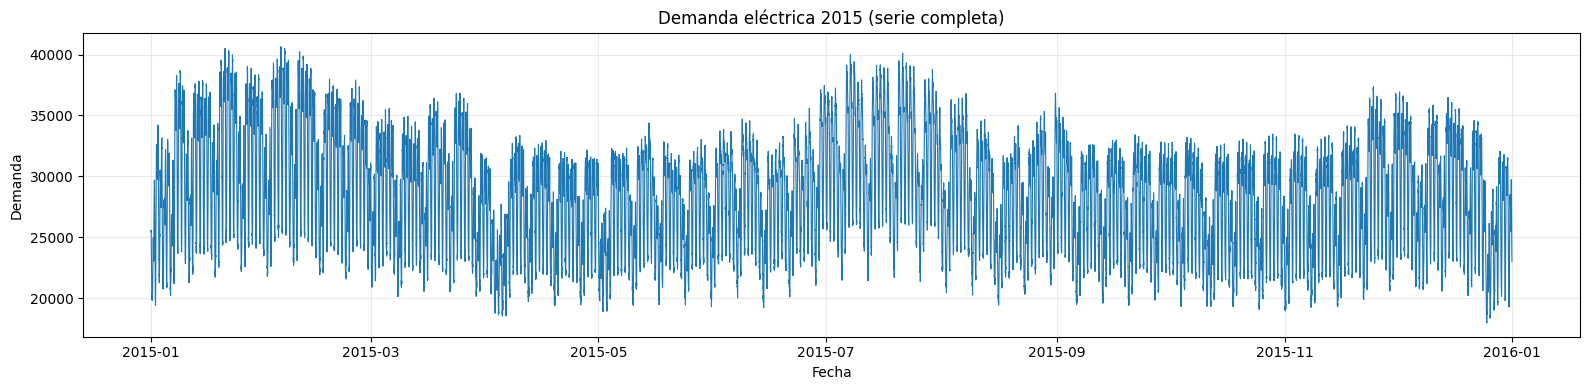

Rango temporal: 2015-01-01 00:00:00 -> 2015-12-31 23:50:00
Número de registros: 52560
Valores nulos en demanda: 0


In [67]:
# Paso 1: vista global de la serie
df_plot = df.copy()
df_plot['demand'] = pd.to_numeric(df_plot['demand'], errors='coerce')
df_plot = df_plot.sort_values('date_hour')

plt.figure(figsize=(16, 4))
plt.plot(df_plot.index, df_plot['demand'], linewidth=0.8)
plt.title('Demanda eléctrica 2015 (serie completa)')
plt.xlabel('Fecha')
plt.ylabel('Demanda')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print('Rango temporal:', df_plot.index.min(), '->', df_plot.index.max())
print('Número de registros:', len(df_plot))
print('Valores nulos en demanda:', df_plot['demand'].isna().sum())

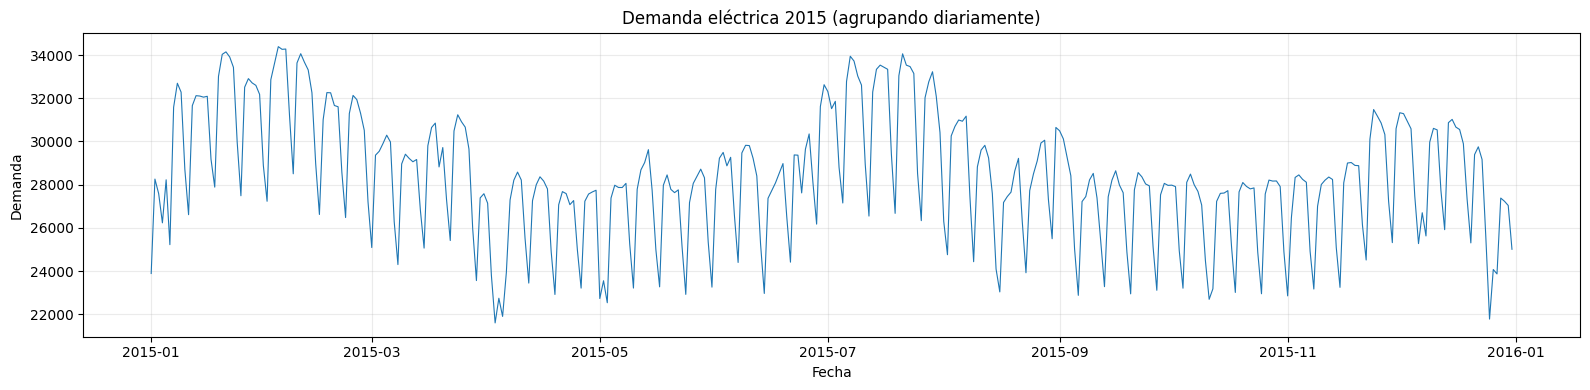

In [94]:
# Paso 2: vista de la serie diariamente
df_daily = df['demand'].resample("D").mean()


plt.figure(figsize=(16, 4))
plt.plot(df_daily.index, df_daily, linewidth=0.8)
plt.title('Demanda eléctrica 2015 (agrupando diariamente)')
plt.xlabel('Fecha')
plt.ylabel('Demanda')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

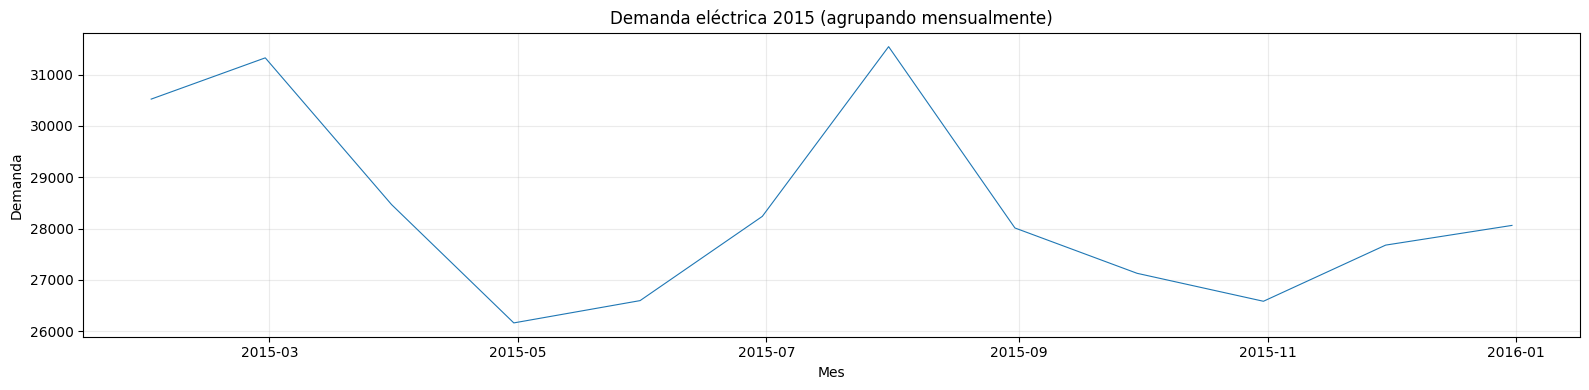

In [97]:
# Paso 3: Vista de la serie mensualmente
df_monthly = df['demand'].resample("ME").mean()

plt.figure(figsize=(16, 4))
plt.plot(df_monthly.index, df_monthly, linewidth=0.8)
plt.title('Demanda eléctrica 2015 (agrupando mensualmente)')
plt.xlabel('Mes')
plt.ylabel('Demanda')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

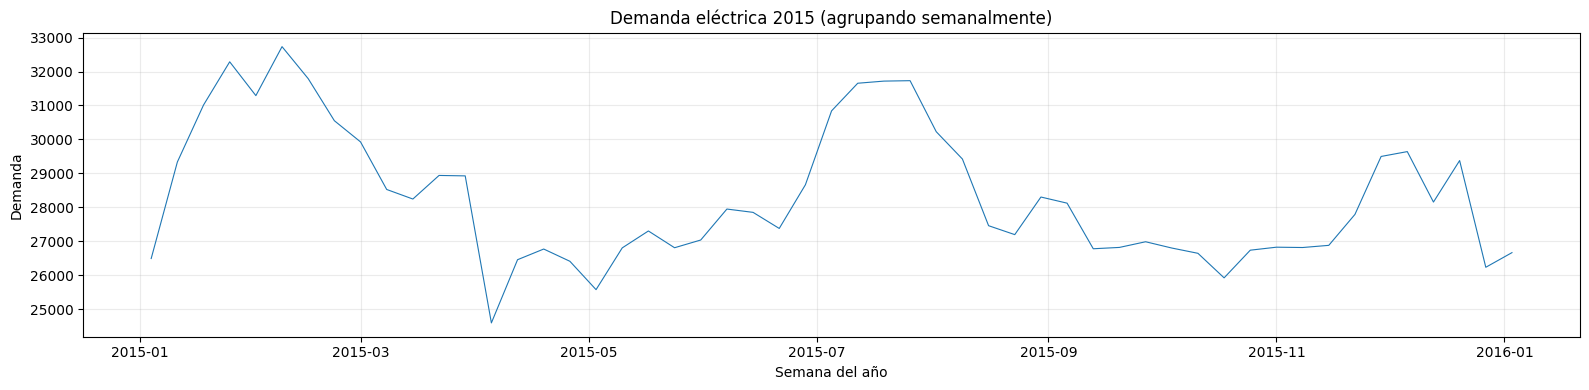

In [98]:
# Paso 4: vista de la serie semanalmente
df_weekly = df['demand'].resample("W").mean()

plt.figure(figsize=(16, 4))
plt.plot(df_weekly.index, df_weekly, linewidth=0.8)
plt.title('Demanda eléctrica 2015 (agrupando semanalmente)')
plt.xlabel('Semana del año')
plt.ylabel('Demanda')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

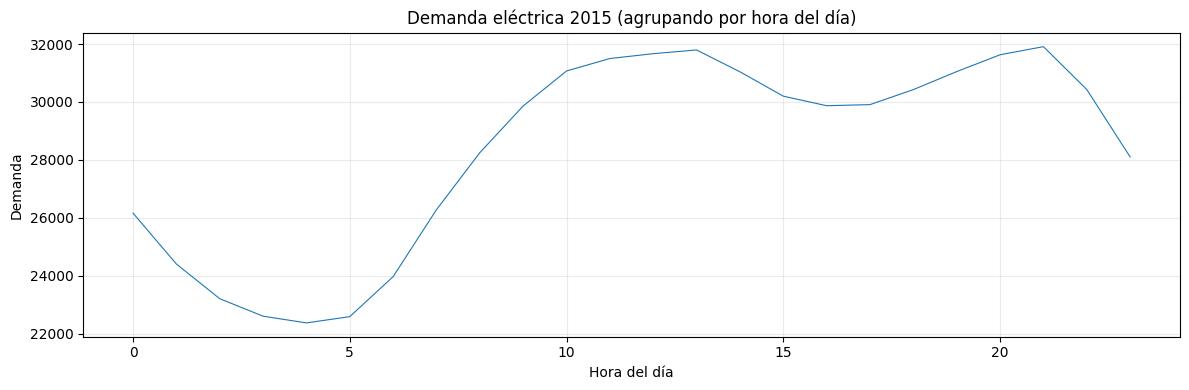

In [102]:
# Paso 5: Vista de la serie por hora del día
df_grouped = df_plot.groupby('hour')['demand'].mean()

plt.figure(figsize=(12, 4))
plt.plot(df_grouped.index, df_grouped, linewidth=0.8)
plt.title('Demanda eléctrica 2015 (agrupando por hora del día)')
plt.xlabel('Hora del día')
plt.ylabel('Demanda')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

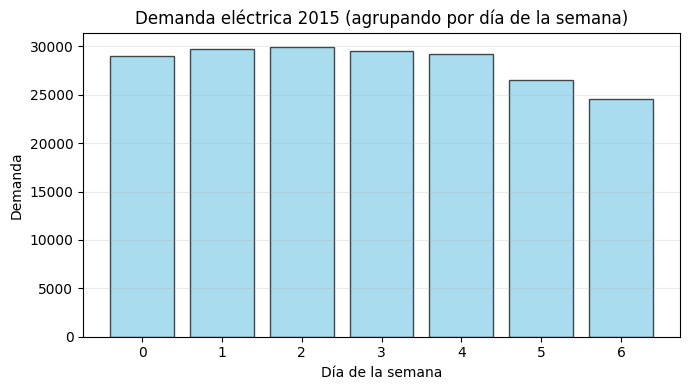

In [ ]:
# Paso 5: Vista de la serie por día de la semana
df_wod = df_plot.groupby('weekday')['demand'].mean()

plt.figure(figsize=(7, 4))
plt.bar(df_wod.index, df_wod, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Demanda eléctrica 2015 (agrupando por día de la semana)')
plt.xlabel('Día de la semana')
plt.ylabel('Demanda')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

## 1.2 Tendencia global

Vamos a ver la tendencia global de la serie, para ello la represntamos junto con sus medias móviles. También la media diaria junto con sus medias móviles.

In [ ]:
df_daily = df["demand"].resample("D").mean()
df_weekly = df["demand"].resample("W").mean()

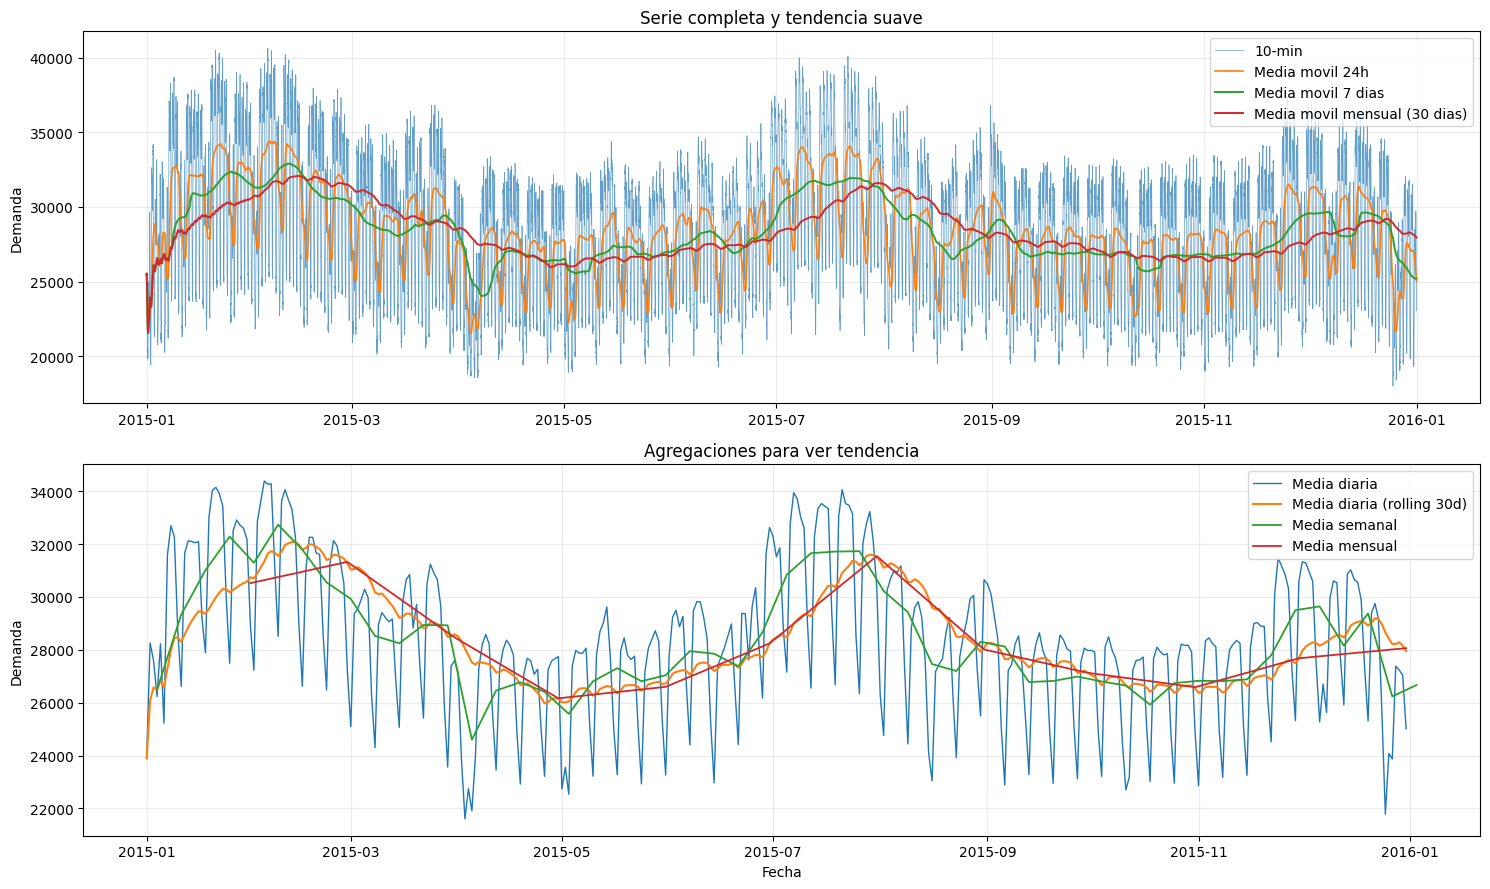

In [110]:
fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=False)

axes[0].plot(df.index, df["demand"], linewidth=0.5, alpha=0.7, label="10-min")
axes[0].plot(
        df["demand"].rolling(24 * 6, min_periods=1).mean(),
        linewidth=1.2,
        label="Media movil 24h",
    )
axes[0].plot(
        df["demand"].rolling(24 * 6 * 7, min_periods=1).mean(),
        linewidth=1.4,
        label="Media movil 7 dias",
    )
axes[0].plot(
        df["demand"].rolling(24 * 6 * 30, min_periods=1).mean(),
        linewidth=1.4,
        label="Media movil mensual (30 dias)",
    )
axes[0].set_title("Serie completa y tendencia suave")
axes[0].set_ylabel("Demanda")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(df_daily.index, df_daily.values, label="Media diaria", linewidth=1.0)
axes[1].plot(df_daily.rolling(30, min_periods=1).mean(), label="Media diaria (rolling 30d)", linewidth=1.5)
axes[1].plot(df_weekly.index, df_weekly.values, label="Media semanal", linewidth=1.3)
axes[1].plot(df_monthly.index, df_monthly.values, label="Media mensual", linewidth=1.3)
axes[1].set_title("Agregaciones para ver tendencia")
axes[1].set_xlabel("Fecha")
axes[1].set_ylabel("Demanda")
axes[1].legend()
axes[1].grid(alpha=0.25)

fig.tight_layout()
plt.show()

In [197]:
# Vamos a ver la tendencia de la serie usando regresión lineal sobre la serie diaria:
eje_x = np.arange(len(df))
eje_y = df.demand.values

# linregress calcula la línea de mejor ajuste
resultado_regresion = linregress(eje_x, eje_y)
pendiente_10_min = resultado_regresion.slope

# Como hay datos cada 10 minutos, la pendiente pura es "crecimiento por cada 10 min".
crecimiento_mensual = pendiente_10_min * 6*24*30
crecimiento_anual = pendiente_10_min * 6*24*365 # 1 año

print("\nANÁLISIS DE TENDENCIA:\n")
print(f"Pendiente: {pendiente_10_min}")
print(f"Cambio estimado al MES:  {crecimiento_mensual:.4f} MW")
print(f"Cambio estimado al AÑO:  {crecimiento_anual:.4f} MW")
print(f"(P-valor de la tendencia: {resultado_regresion.pvalue:.4e})")
    


ANÁLISIS DE TENDENCIA:

Pendiente: -0.04566166699801732
Cambio estimado al MES:  -197.2584 MW
Cambio estimado al AÑO:  -2399.9772 MW
(P-valor de la tendencia: 3.7602e-256)


In [196]:
print("\nESTADÍSTICOS BÁSICOS Y VARIABILIDAD:\n")
    
stats = df.demand.describe()
    
# Calculamos cosas extra: Varianza, Rango y Coeficiente de Variación (CV)
varianza = df.demand.var()
rango = stats['max'] - stats['min']
rango_intercuartil = stats['75%'] - stats['25%'] # IQR (Robusto a outliers)
cv_global = (stats['std'] / stats['mean']) * 100
    
print(f"Demanda Media Promedio: {stats['mean']:.2f} MW")
print(f"Mediana:{stats['50%']:.2f} MW")
print(f"Mínimo Absoluto: {stats['min']:.2f} MW")
print(f"Máximo Absoluto: {stats['max']:.2f} MW")
print("-" * 30)
print(f"Desviación Típica (Std): {stats['std']:.2f} MW")
print(f"Variabilidad Relativa (CV): {cv_global:.2f}%")
print(f"Rango Total (Max - Min):{rango:.2f} MW")
print(f"Rango Intercuartil (IQR):{rango_intercuartil:.2f} MW ")


ESTADÍSTICOS BÁSICOS Y VARIABILIDAD:

Demanda Media Promedio: 28348.61 MW
Mediana:28566.00 MW
Mínimo Absoluto: 17985.00 MW
Máximo Absoluto: 40648.00 MW
------------------------------
Desviación Típica (Std): 4671.82 MW
Variabilidad Relativa (CV): 16.48%
Rango Total (Max - Min):22663.00 MW
Rango Intercuartil (IQR):7272.00 MW 


In [198]:
2400/28348.61

0.08466023554594035

## 1.3 Variabilidad de la serie

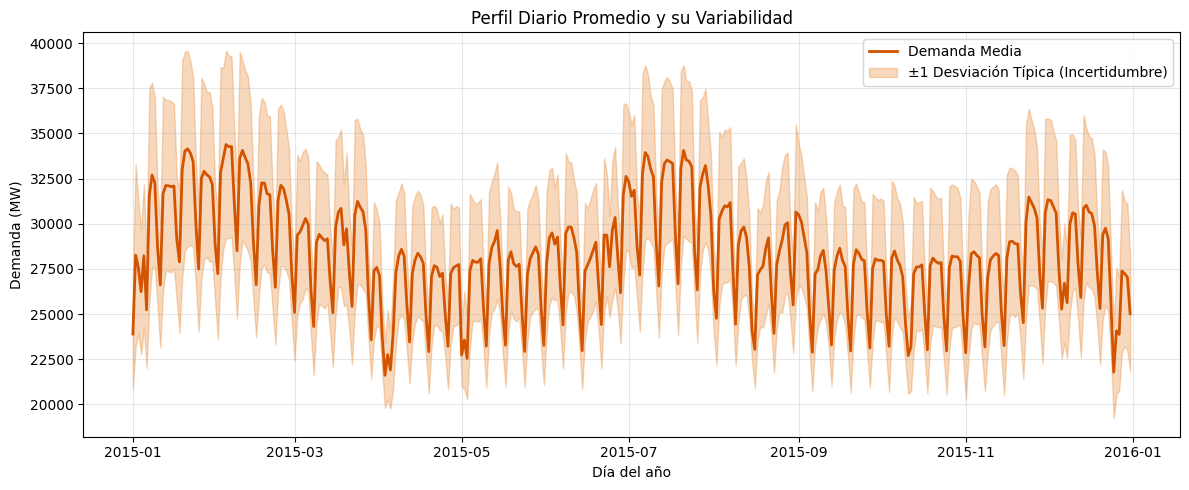

In [ ]:
df_daily = df['demand'].resample("D").agg(['mean', 'std'])

plt.figure(figsize=(12, 5))
plt.plot(df_daily.index, df_daily['mean'], color='#d35400', linewidth=2, label='Demanda Media')

# Sombra que representa la media +/- 1 desviación típica
plt.fill_between(df_daily.index, 
                 df_daily['mean'] - df_daily['std'], 
                 df_daily['mean'] + df_daily['std'], 
                 color='#e67e22', alpha=0.3, label='±1 Desviación Típica (Incertidumbre)')

plt.title('Perfil Diario Promedio y su Variabilidad')
plt.xlabel('Día del año')
plt.ylabel('Demanda (MW)')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

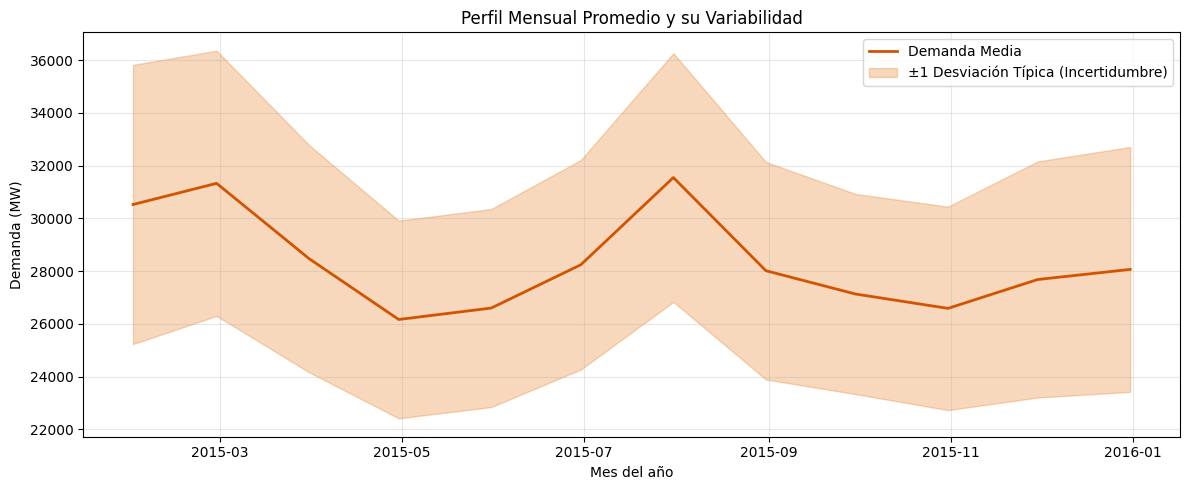

In [170]:
df_monthly = df['demand'].resample("ME").agg(['mean', 'std'])

plt.figure(figsize=(12, 5))
plt.plot(df_monthly.index, df_monthly['mean'], color='#d35400', linewidth=2, label='Demanda Media')

# Sombra que representa la media +/- 1 desviación típica
plt.fill_between(df_monthly.index, 
                 df_monthly['mean'] - df_monthly['std'], 
                 df_monthly['mean'] + df_monthly['std'], 
                 color='#e67e22', alpha=0.3, label='±1 Desviación Típica (Incertidumbre)')

plt.title('Perfil Mensual Promedio y su Variabilidad')
plt.xlabel('Mes del año')
plt.ylabel('Demanda (MW)')


plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

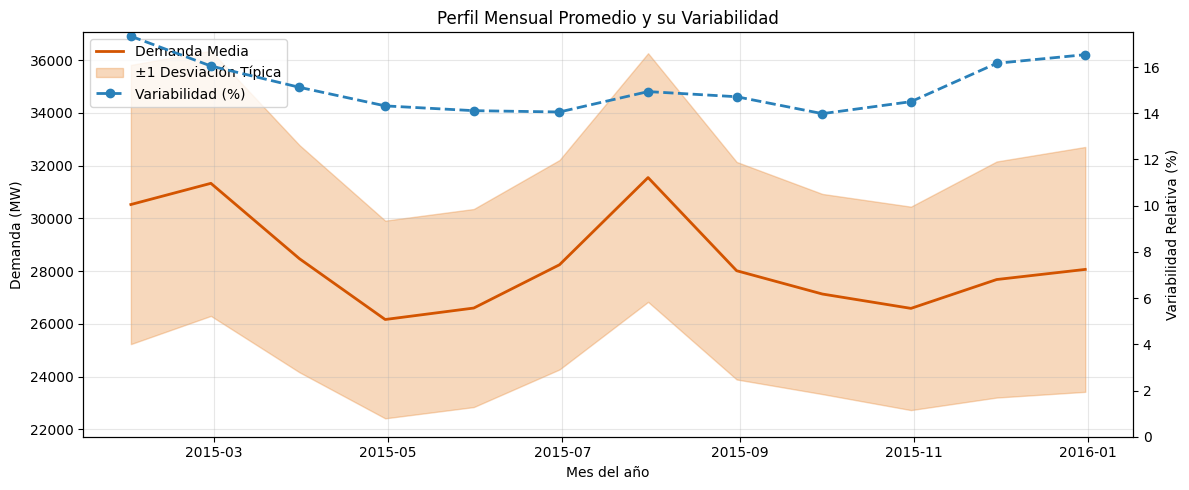

In [ ]:
# 1. Agrupamos y calculamos (Asumo que ya lo tienes, se añade el %)
df_monthly = df['demand'].resample("ME").agg(['mean', 'std'])
df_monthly['variabilidad_pct'] = (df_monthly['std'] / df_monthly['mean']) * 100

# 2. Creamos la figura y el eje principal (ax1)
fig, ax1 = plt.subplots(figsize=(12, 5))


ax1.plot(df_monthly.index, df_monthly['mean'], color='#d35400', linewidth=2, label='Demanda Media')

# Sombra que representa la media +/- 1 desviación típica
ax1.fill_between(df_monthly.index, 
                 df_monthly['mean'] - df_monthly['std'], 
                 df_monthly['mean'] + df_monthly['std'], 
                 color='#e67e22', alpha=0.3, label='±1 Desviación Típica')

ax1.set_xlabel('Mes del año')
ax1.set_ylabel('Demanda (MW)')

# --- EL AÑADIDO: LA LÍNEA DE VARIABILIDAD (Eje Secundario) ---
ax2 = ax1.twinx()
color_var = '#2980b9' # Azul para contrastar con el naranja

# Añadimos la línea punteada para el porcentaje
ax2.plot(df_monthly.index, df_monthly['variabilidad_pct'], color=color_var, linewidth=2, linestyle='--', marker='o', label='Variabilidad (%)')
ax2.set_ylabel('Variabilidad Relativa (%)')
ax2.set_ylim(bottom=0) # Fija el mínimo en 0 para que el % tenga una escala lógica

# --- TÍTULOS Y LEYENDAS ---
plt.title('Perfil Mensual Promedio y su Variabilidad')

# Unimos las leyendas de ambos ejes en un solo cuadro
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

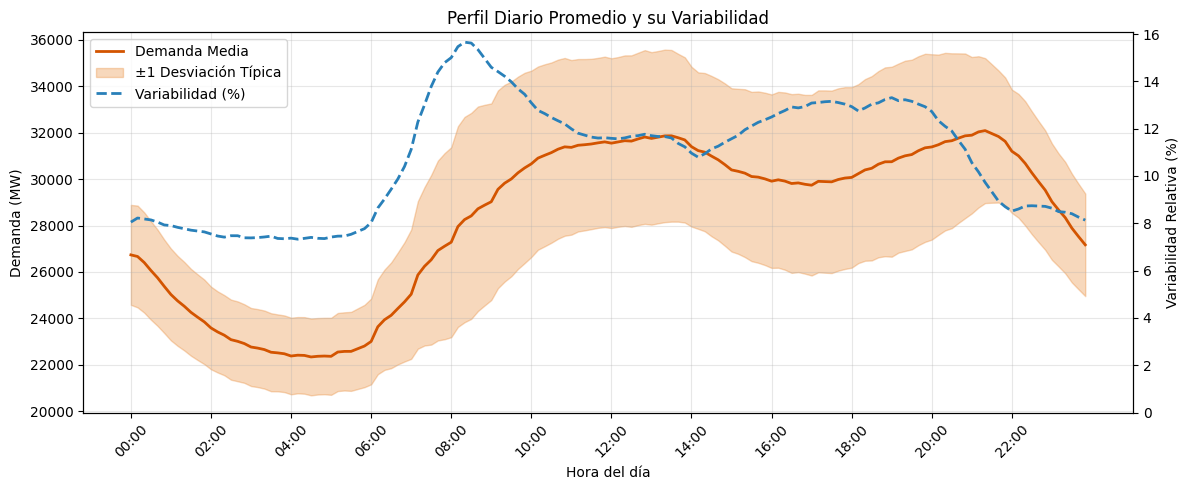

In [219]:
# 1. Agrupamos y calculamos (Asumo que ya lo tienes, se añade el %)
df_daily = df.groupby('hour_minute')['demand'].agg(['mean', 'std'])
df_daily['variabilidad_pct'] = (df_daily['std'] / df_daily['mean']) * 100

eje_x = df_daily.index

# 2. Creamos la figura y el eje principal (ax1)
fig, ax1 = plt.subplots(figsize=(12, 5))


ax1.plot(eje_x, df_daily['mean'], color='#d35400', linewidth=2, label='Demanda Media')

# Sombra que representa la media +/- 1 desviación típica
ax1.fill_between(eje_x, 
                 df_daily['mean'] - df_daily['std'], 
                 df_daily['mean'] + df_daily['std'], 
                 color='#e67e22', alpha=0.3, label='±1 Desviación Típica')

ax1.set_xlabel('Hora del día')
ax1.set_ylabel('Demanda (MW)')

# --- EL AÑADIDO: LA LÍNEA DE VARIABILIDAD (Eje Secundario) ---
ax2 = ax1.twinx()
color_var = '#2980b9' # Azul para contrastar con el naranja

# Añadimos la línea punteada para el porcentaje
ax2.plot(eje_x, df_daily['variabilidad_pct'], color=color_var, linewidth=2, linestyle='--', label='Variabilidad (%)')
ax2.set_ylabel('Variabilidad Relativa (%)')
ax2.set_ylim(bottom=0) # Fija el mínimo en 0 para que el % tenga una escala lógica

# --- TÍTULOS Y LEYENDAS ---
plt.title('Perfil Diario Promedio y su Variabilidad')

# Unimos las leyendas de ambos ejes en un solo cuadro
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

step = 12  # por ejemplo: uno cada 12 puntos (ajusta según tu frecuencia)

ax1.set_xticks(eje_x[::step])
ax1.set_xticklabels(eje_x[::step], rotation=45)

ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

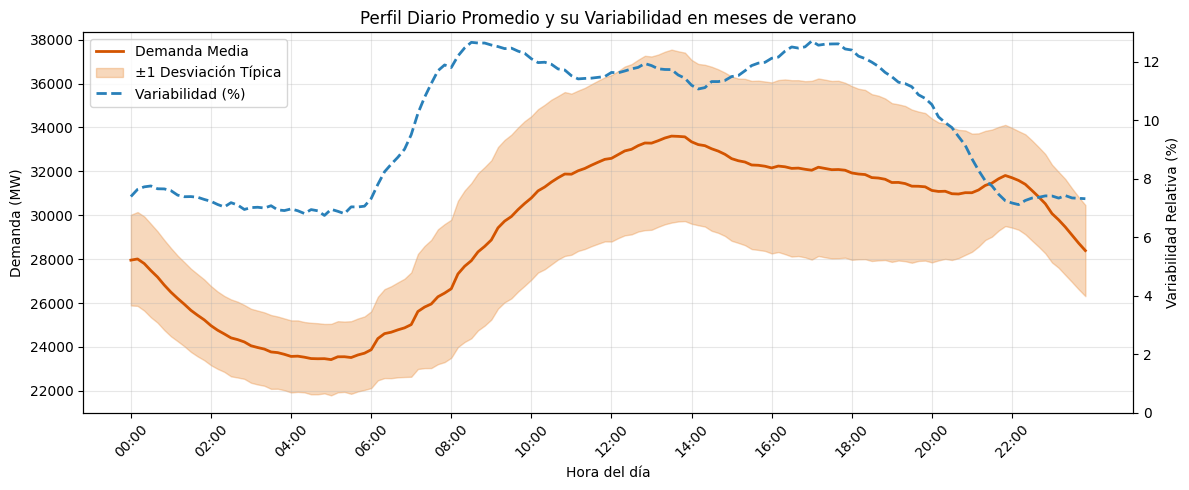

In [524]:
# 1. Agrupamos y calculamos (Asumo que ya lo tienes, se añade el %)
df_daily = df[df['month'].isin([6, 7, 8])].groupby('hour_minute')['demand'].agg(['mean', 'std'])
df_daily['variabilidad_pct'] = (df_daily['std'] / df_daily['mean']) * 100

eje_x = df_daily.index

# 2. Creamos la figura y el eje principal (ax1)
fig, ax1 = plt.subplots(figsize=(12, 5))


ax1.plot(eje_x, df_daily['mean'], color='#d35400', linewidth=2, label='Demanda Media')

# Sombra que representa la media +/- 1 desviación típica
ax1.fill_between(eje_x, 
                 df_daily['mean'] - df_daily['std'], 
                 df_daily['mean'] + df_daily['std'], 
                 color='#e67e22', alpha=0.3, label='±1 Desviación Típica')

ax1.set_xlabel('Hora del día')
ax1.set_ylabel('Demanda (MW)')

# --- EL AÑADIDO: LA LÍNEA DE VARIABILIDAD (Eje Secundario) ---
ax2 = ax1.twinx()
color_var = '#2980b9' # Azul para contrastar con el naranja

# Añadimos la línea punteada para el porcentaje
ax2.plot(eje_x, df_daily['variabilidad_pct'], color=color_var, linewidth=2, linestyle='--', label='Variabilidad (%)')
ax2.set_ylabel('Variabilidad Relativa (%)')
ax2.set_ylim(bottom=0) # Fija el mínimo en 0 para que el % tenga una escala lógica

# --- TÍTULOS Y LEYENDAS ---
plt.title('Perfil Diario Promedio y su Variabilidad en meses de verano')

# Unimos las leyendas de ambos ejes en un solo cuadro
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

step = 12  # por ejemplo: uno cada 12 puntos (ajusta según tu frecuencia)

ax1.set_xticks(eje_x[::step])
ax1.set_xticklabels(eje_x[::step], rotation=45)

ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

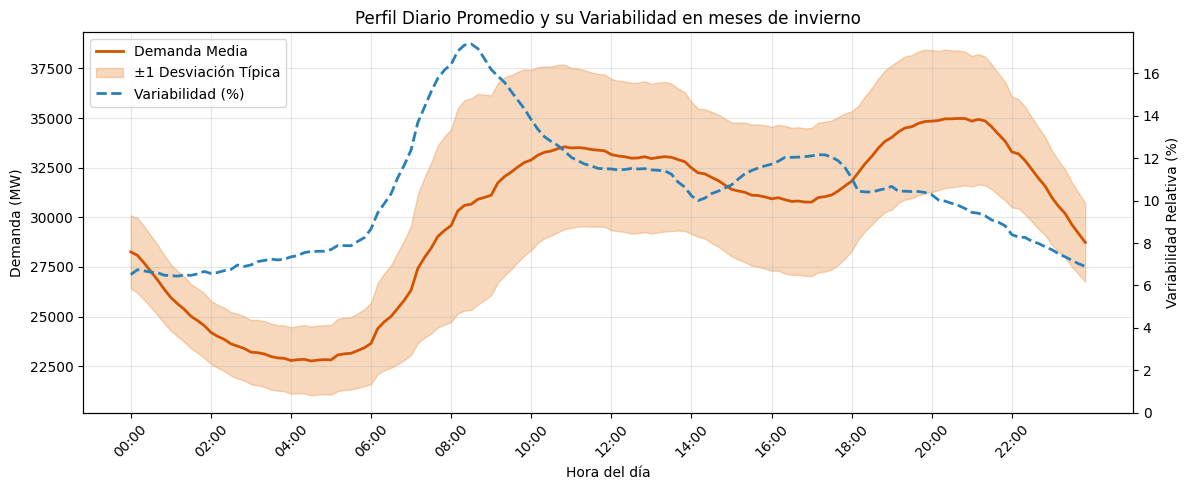

In [523]:
# 1. Agrupamos y calculamos (Asumo que ya lo tienes, se añade el %)
df_daily = df[df['month'].isin([1, 2, 12])].groupby('hour_minute')['demand'].agg(['mean', 'std'])
df_daily['variabilidad_pct'] = (df_daily['std'] / df_daily['mean']) * 100

eje_x = df_daily.index

# 2. Creamos la figura y el eje principal (ax1)
fig, ax1 = plt.subplots(figsize=(12, 5))


ax1.plot(eje_x, df_daily['mean'], color='#d35400', linewidth=2, label='Demanda Media')

# Sombra que representa la media +/- 1 desviación típica
ax1.fill_between(eje_x, 
                 df_daily['mean'] - df_daily['std'], 
                 df_daily['mean'] + df_daily['std'], 
                 color='#e67e22', alpha=0.3, label='±1 Desviación Típica')

ax1.set_xlabel('Hora del día')
ax1.set_ylabel('Demanda (MW)')

# --- EL AÑADIDO: LA LÍNEA DE VARIABILIDAD (Eje Secundario) ---
ax2 = ax1.twinx()
color_var = '#2980b9' # Azul para contrastar con el naranja

# Añadimos la línea punteada para el porcentaje
ax2.plot(eje_x, df_daily['variabilidad_pct'], color=color_var, linewidth=2, linestyle='--', label='Variabilidad (%)')
ax2.set_ylabel('Variabilidad Relativa (%)')
ax2.set_ylim(bottom=0) # Fija el mínimo en 0 para que el % tenga una escala lógica

# --- TÍTULOS Y LEYENDAS ---
plt.title('Perfil Diario Promedio y su Variabilidad en meses de invierno')

# Unimos las leyendas de ambos ejes en un solo cuadro
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

step = 12  # por ejemplo: uno cada 12 puntos (ajusta según tu frecuencia)

ax1.set_xticks(eje_x[::step])
ax1.set_xticklabels(eje_x[::step], rotation=45)

ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

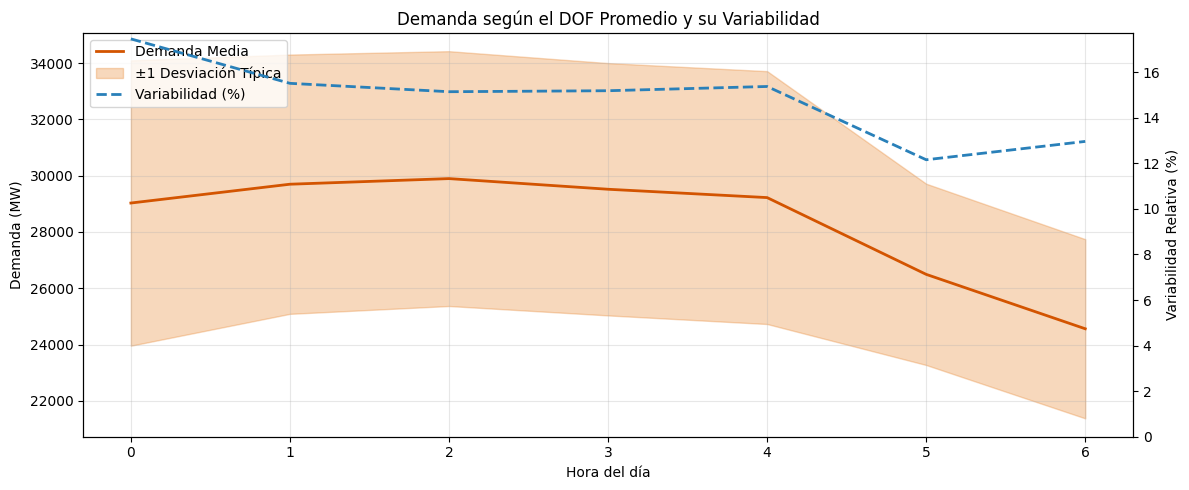

In [525]:
# 1. Agrupamos y calculamos (Asumo que ya lo tienes, se añade el %)
df_daily = df.groupby('weekday')['demand'].agg(['mean', 'std'])
df_daily['variabilidad_pct'] = (df_daily['std'] / df_daily['mean']) * 100

eje_x = df_daily.index

# 2. Creamos la figura y el eje principal (ax1)
fig, ax1 = plt.subplots(figsize=(12, 5))


ax1.plot(eje_x, df_daily['mean'], color='#d35400', linewidth=2, label='Demanda Media')

# Sombra que representa la media +/- 1 desviación típica
ax1.fill_between(eje_x, 
                 df_daily['mean'] - df_daily['std'], 
                 df_daily['mean'] + df_daily['std'], 
                 color='#e67e22', alpha=0.3, label='±1 Desviación Típica')

ax1.set_xlabel('Hora del día')
ax1.set_ylabel('Demanda (MW)')

# --- EL AÑADIDO: LA LÍNEA DE VARIABILIDAD (Eje Secundario) ---
ax2 = ax1.twinx()
color_var = '#2980b9' # Azul para contrastar con el naranja

# Añadimos la línea punteada para el porcentaje
ax2.plot(eje_x, df_daily['variabilidad_pct'], color=color_var, linewidth=2, linestyle='--', label='Variabilidad (%)')
ax2.set_ylabel('Variabilidad Relativa (%)')
ax2.set_ylim(bottom=0) # Fija el mínimo en 0 para que el % tenga una escala lógica

# --- TÍTULOS Y LEYENDAS ---
plt.title('Demanda según el DOF Promedio y su Variabilidad')

# Unimos las leyendas de ambos ejes en un solo cuadro
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [526]:
df_daily

,mean,std,variabilidad_pct
weekday,,,
0,29028.927484,5069.300785,17.462928
1,29697.218082,4606.478212,15.511481
2,29896.772436,4527.496369,15.143763
3,29518.291536,4482.991183,15.187163
4,29222.031651,4492.431530,15.373440
5,26494.022703,3220.865635,12.156952
6,24560.541800,3183.553194,12.962064


Observando la serie vemos que los meses de invierno (enero-febrero) la demanda es mayor, al igual que el verano (mediados de julio y agosto) y, en temporadas más suaves como la primavera y el otoño es donde se tienen los valles de demanda. Esto se debe al uso de aire acondicionado en verano y calentadores en invierno, algo que, en general, no está presente en el resto de temporadas.

Respecto a la tendencia global de la serie, visualmente no se ve  ninguna. Calculando la regresión lineal observamos que tiene una pendiente de $-0.045$ y con un p-valor casi $0$ por lo que estadísticamente sí hay una tendencia. Sin embargo, en la práctica esta tendencia es tan pequeña que es insignificativa, de hecho, la variación provocada por esta "tendencia" es menor que las fluctuaciones naturales producida por la variabilidad de la propia serie, un $16.48\%$.

En cuanto a la demanda a nivel diario, los días de la semana con una menor demanda son los fines de semana, siendo el domingo un $16.6\%$ menor que los días de diario. Sin embargo, los fines de semana son los días con una menor variabilidad. A nivel horario, hay dos claros picos de demanda, el primero a mediodía (en torno a la 13) y el segundo a última hora del día (en torno a las 21). Lógicamente, el valle de demanda se obtiene a las 4 de la mañana, y la variabilidad en la madrugada es mucho menor que en el resto de horas. La mayor vairabilidad se tiene a las 8 de la mañana, coincidiendo con las horas en que la gente empieza a trabajar, ir al colegio, etc.

In [230]:


def plot_acf_pacf_comparativa(serie_original, lags_acf=400):
    """
    Genera un panel con ACF y PACF de la serie original 
    y la serie diferenciada estacionalmente (diaria).
    """
    # 1. Calcular la serie diferenciada (Asumiendo frecuencia de 10 min -> s=144)
    serie_dif_estacional = serie_original.diff(144).dropna()
    
    # 2. Configurar el panel de gráficos (2 filas, 2 columnas)
    fig, axes = plt.subplots(3, 2, figsize=(16, 12))
    
    # --- FILA 1: Serie Original ---
    # ACF Original
    plot_acf(serie_original.dropna(), ax=axes[0, 0], lags=lags_acf, alpha=0.05)
    axes[0, 0].set_title("ACF serie original")
    axes[0, 0].set_ylim(-1.0, 1.0) # Fija los límites de Y a [-1, 1]
    
    # PACF Original
    # Nota: Para el PACF se suelen usar menos lags (ej. 120) porque calcularlo 
    # a 400 lags es muy costoso computacionalmente y suele dar errores matemáticos.
    plot_pacf(serie_original.dropna(), ax=axes[0, 1], lags=120, alpha=0.05)
    axes[0, 1].set_title("PACF serie original")
    axes[0, 1].set_ylim(-1.0, 1.0)
    
    # --- FILA 2: Serie Diferenciada diaria ---

    plot_acf(serie_dif_estacional, ax=axes[1, 0], lags=lags_acf, alpha=0.05)
    axes[1, 0].set_title("ACF serie diferenciada diaria")
    axes[1, 0].set_ylim(-1.0, 1.0)
    

    plot_pacf(serie_dif_estacional, ax=axes[1, 1], lags=120, alpha=0.05)
    axes[1, 1].set_title("PACF serie diferenciada diaria")
    axes[1, 1].set_ylim(-1.0, 1.0)
    
    # --- FILA 3: Serie Diferenciada doblemente (diaria + otra) ---

    serie_doble_dif = serie_dif_estacional.diff(1).dropna()

    plot_acf(serie_doble_dif, ax=axes[2, 0], lags=lags_acf, alpha=0.05)
    axes[2, 0].set_title("3. ACF Doble Dif (Estacional + Regular)")
    axes[2, 0].set_ylim(-1.0, 1.0)
    
    plot_pacf(serie_doble_dif, ax=axes[2, 1], lags=120, alpha=0.05)
    axes[2, 1].set_title("3. PACF Doble Dif (Estacional + Regular)")
    axes[2, 1].set_ylim(-1.0, 1.0)
    
    # Ajuste visual
    plt.tight_layout()
    plt.show()


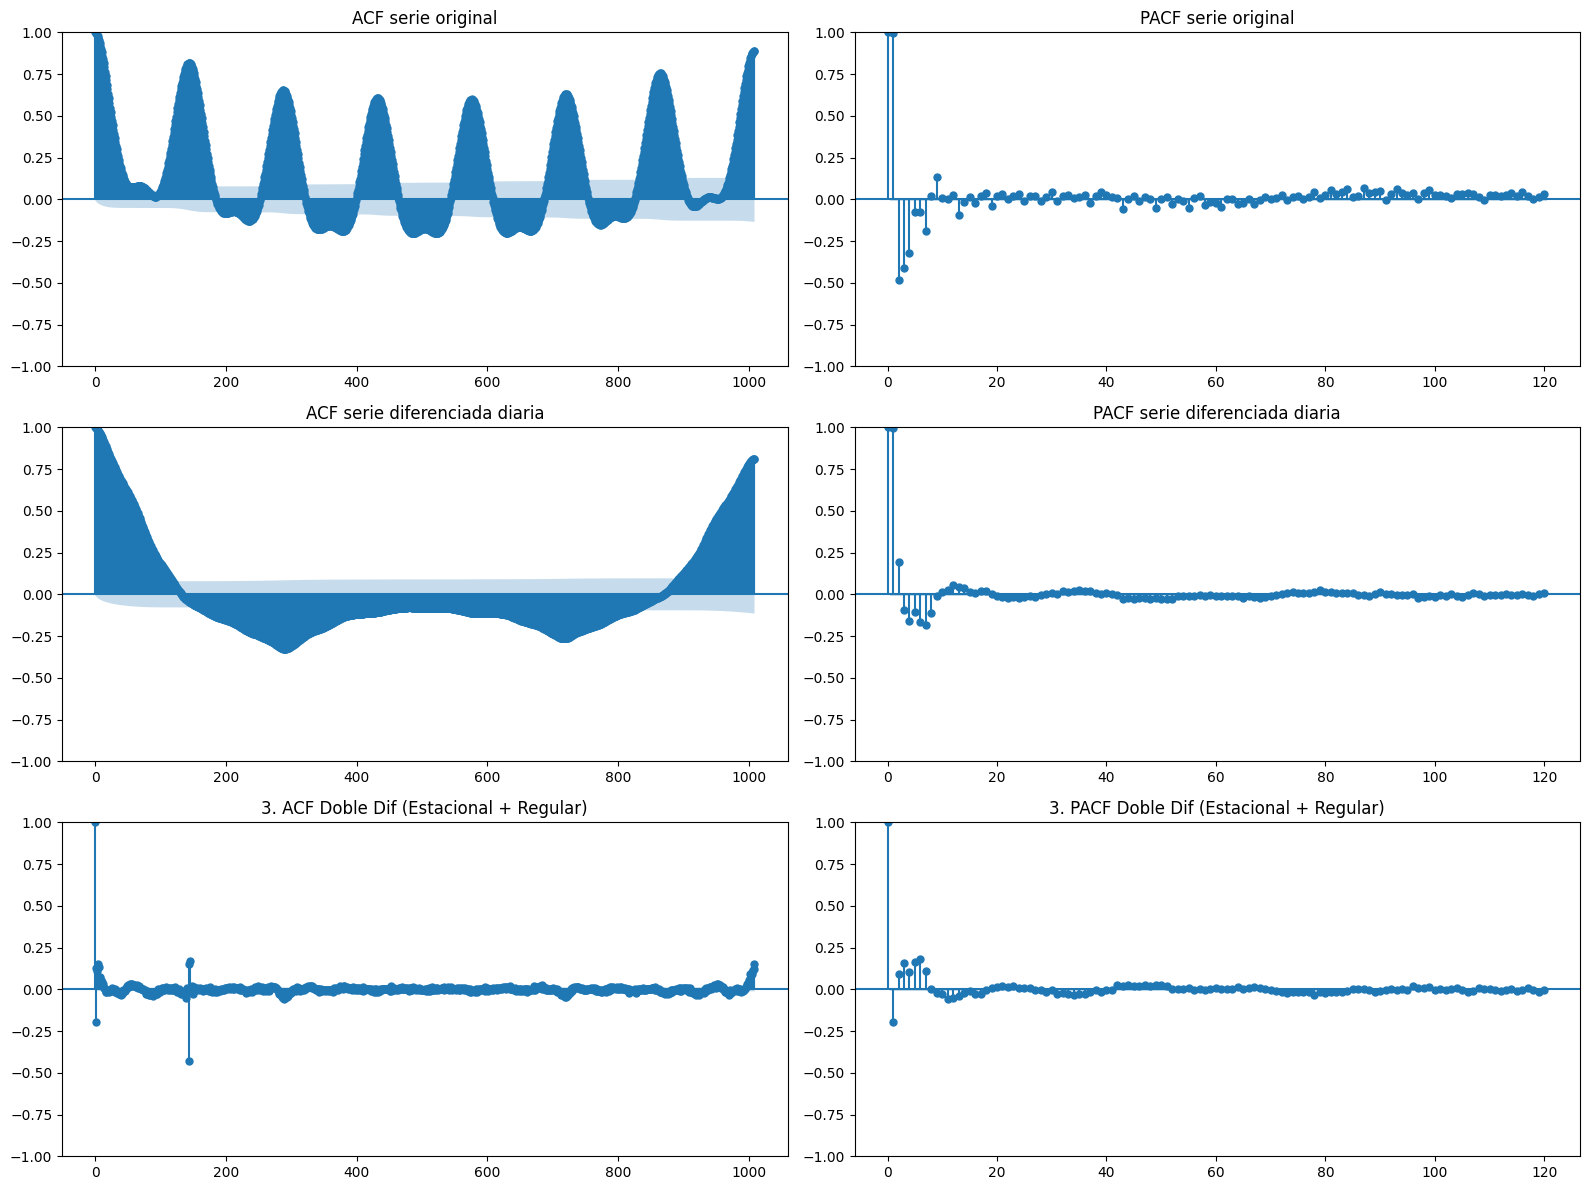

In [232]:
plot_acf_pacf_comparativa(df['demand'], 1008)

La función de ACF (Autocorrelation Function) mide cuánto se parece la serie consigo misma en distintos retardos (lag 1 el instante anteior, lag 144 el mismo momento dle día anterior, etc). La intuición de esto es: ¿si ahora la demanda es alta también lo era hace X pasos?

Por su parte PACF (Partia ACF) mide la correlación directa entre dos puntos eliminando el efecto intermedio. La intución es: ¿este lag aporta indormación nueva o solo viene arrastrado por otros lags?

En los modelos ARIMA y SARIMA, ACF sugiere la componente MA(q) y PACF sugiere la componente AR(p) y los picos en múltiplos de un lag nos muestran la estacionalidad de la serie.


Teniendo todo esto en cuenta, observamos que en la serie original ACF tiene una forma sinusoidal fuerta, lo que nos dice que hay una gran estacionalidad diaria, lo cual es razonable dentro del ámbito del consumo eléctrico. Por el contrario, PACF tiene picos grandes en el lag 1 y luego cae rápidamente, esto es típico de procesos con dependencia corta y estacionalidad. Si observamos la serie diferenciada diariamente (es decir, le restamos el valor de hace 144 pasos) esta estacionalidad se pierde, en su lugar vemos el siguiente pico en el valor 1008 (estacionalidad semanal) pero sigue sin ser estacionaria. Tras una segunda diferenciación (144 y luego 1), ACF es mucho más plana y PACF también,  siendo casi una serie estacionaria.

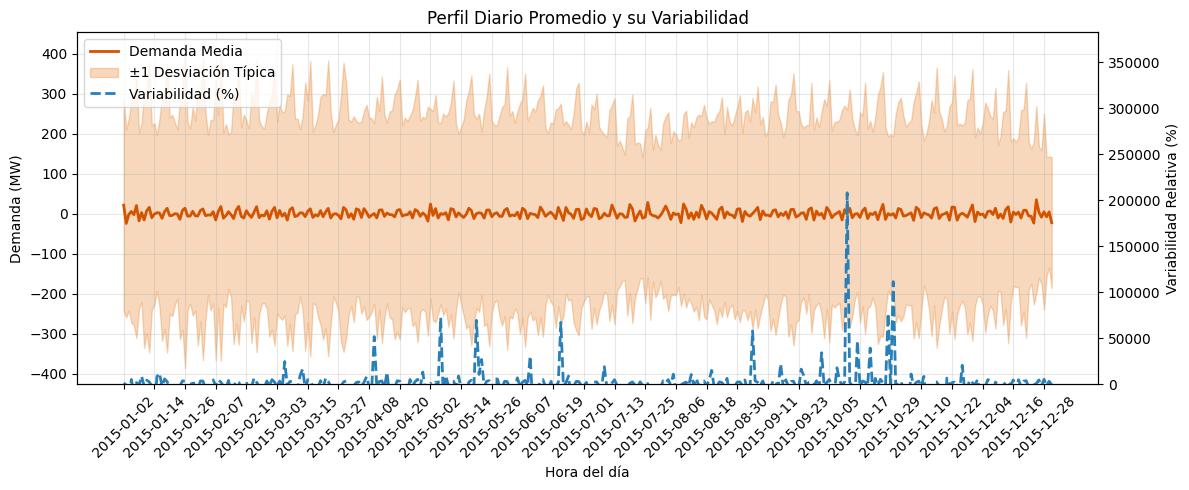

In [ ]:
# 1. Agrupamos y calculamos (Asumo que ya lo tienes, se añade el %)
df_estacional = pd.DataFrame(serie_dif_estacional)
df_estacional['date_hour'] = df_estacional.index
df_estacional['date'] = df_estacional['date_hour'].dt.date

df_daily = df_estacional.groupby('date')['demand'].agg(['mean', 'std'])
df_daily['variabilidad_pct'] = (df_daily['std'] / df_daily['mean']) * 100

eje_x = df_daily.index

# 2. Creamos la figura y el eje principal (ax1)
fig, ax1 = plt.subplots(figsize=(12, 5))


ax1.plot(eje_x, df_daily['mean'], color='#d35400', linewidth=2, label='Demanda Media')

# Sombra que representa la media +/- 1 desviación típica
ax1.fill_between(eje_x, 
                 df_daily['mean'] - df_daily['std'], 
                 df_daily['mean'] + df_daily['std'], 
                 color='#e67e22', alpha=0.3, label='±1 Desviación Típica')

ax1.set_xlabel('Hora del día')
ax1.set_ylabel('Demanda (MW)')

# --- EL AÑADIDO: LA LÍNEA DE VARIABILIDAD (Eje Secundario) ---
ax2 = ax1.twinx()
color_var = '#2980b9' # Azul para contrastar con el naranja

# Añadimos la línea punteada para el porcentaje
ax2.plot(eje_x, df_daily['variabilidad_pct'], color=color_var, linewidth=2, linestyle='--', label='Variabilidad (%)')
ax2.set_ylabel('Variabilidad Relativa (%)')
ax2.set_ylim(bottom=0) # Fija el mínimo en 0 para que el % tenga una escala lógica

# --- TÍTULOS Y LEYENDAS ---
plt.title('Perfil Diario Promedio y su Variabilidad de la serie estacionaria')

# Unimos las leyendas de ambos ejes en un solo cuadro
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

step = 12  # por ejemplo: uno cada 12 puntos (ajusta según tu frecuencia)

ax1.set_xticks(eje_x[::step])
ax1.set_xticklabels(eje_x[::step], rotation=45)

ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Estudio de Outliers

## 2.1 Estudio "clásico"

En este primer estudio vamos a usar cuatro métodos:

- El primero de los métodos es un estudio clásico de IQR para detectar outliers globales, es decir, para detectar outliers respecto a la distribución general. Este método es complicado que detecte outliers (a no ser que sean muy claros) ya que la serie tiene mucha variabilidad y depende mucho de las horas y del día de la semana.

- El segundo de ellos es para detectar outliers globales de forma que se alejen más de tres veces de la media global, al igual que el método anterior no es el más robusto ya que la demanda es muy dependiente de la estacionalidad.

- El tercer método tiene en cuenta las diferencias, es decir, detecta cambios bruscos entre instantes consecutivos, este método ya sí es específico de series temporales.

- El cuarto método es ver los outlier contextuales, es decir, se compara cada punto con la media el mismo día de la semana y la misma hora. Es como el segundo método pero teniendo en cuenta el contexto.

In [266]:
# Detección de outliers con múltiples métodos

# Método 1: IQR
Q1 = df['demand'].quantile(0.25)
Q3 = df['demand'].quantile(0.75)
IQR = Q3 - Q1
lower_iqr = Q1 - 1.5 * IQR
upper_iqr = Q3 + 1.5 * IQR
outliers_iqr = df[(df['demand'] < lower_iqr) | (df['demand'] > upper_iqr)]
print(f"Outliers IQR: {len(outliers_iqr)} ({100*len(outliers_iqr)/len(df):.2f}%)")
print(f"  Límite inferior: {lower_iqr:.0f}, Límite superior: {upper_iqr:.0f}")

# Método 2: Z-Score
z_scores = np.abs(stats.zscore(df['demand']))
outliers_z = df[z_scores > 3]
print(f"\nOutliers Z-score (|z|>3): {len(outliers_z)} ({100*len(outliers_z)/len(df):.2f}%)")

# Método 3: Diferencias entre valores consecutivos (spikes)
df['diff'] = df['demand'].diff().abs()
diff_threshold = df['diff'].mean() + 3 * df['diff'].std()
outliers_diff = df[df['diff'] > diff_threshold]
print(f"\nOutliers por diferencia abrupta: {len(outliers_diff)} ({100*len(outliers_diff)/len(df):.2f}%)")

# Combinar outliers IQR
df['is_outlier_iqr'] = (df['demand'] < lower_iqr) | (df['demand'] > upper_iqr)
df['is_outlier_z'] = z_scores > 3

print(f"\nFecha/hora de outliers IQR:")
print(outliers_iqr[['hour_minute','demand']].head(20))

Outliers IQR: 0 (0.00%)
  Límite inferior: 13484, Límite superior: 42572

Outliers Z-score (|z|>3): 0 (0.00%)

Outliers por diferencia abrupta: 720 (1.37%)

Fecha/hora de outliers IQR:
Empty DataFrame
Columns: [hour_minute, demand]
Index: []


In [297]:
# Análisis de outliers más fino: usando contexto de hora del día
# Comparamos con la distribución para cada franja horaria y día de semana

group_stats = df.groupby(['weekday', 'hour'])['demand'].agg(['mean', 'std']).reset_index()
group_stats.columns = ['weekday', 'hour', 'group_mean', 'group_std']

df_merged = df.merge(group_stats, on=['weekday', 'hour'])
df_merged['z_contextual'] = (df_merged['demand'] - df_merged['group_mean']) / df_merged['group_std']

outliers_ctx = df_merged[np.abs(df_merged['z_contextual']) > 3]
print(f"Outliers contextuales (|z|>3 respecto a mismo día/hora): {len(outliers_ctx)} ({100*len(outliers_ctx)/len(df):.2f}%)")
print(f"\nMeses con más outliers:")
print(outliers_ctx.groupby('month').size())
print(f"\nMuestra de outliers:")

Outliers contextuales (|z|>3 respecto a mismo día/hora): 133 (0.25%)

Meses con más outliers:
month
1     32
2     14
4     27
5      1
10     4
12    55
dtype: int64

Muestra de outliers:


In [298]:
outliers_ctx.groupby('date')[['demand', 'group_mean', 'z_contextual']].mean()

,demand,group_mean,z_contextual
date,,,
2015-01-01,22058.100000,32059.179245,-3.335041
2015-01-06,22506.500000,31964.294872,-3.202209
2015-02-04,35378.000000,28434.570513,3.040844
2015-02-07,34681.600000,28461.653205,3.110516
2015-02-08,29485.666667,24405.463675,3.161329
2015-04-03,22306.481481,32442.150522,-3.104656
2015-05-01,23818.000000,32095.929487,-3.051700
2015-10-12,22366.750000,31774.042468,-3.130746
2015-12-25,19864.963636,29145.961364,-3.144541


La serie no presenta outliers a nivel global, lo cual es normal a haber mucha dependencia en la estacionalidad. El tercer método nos dice que en un $1.3\%$ de los casos hay cambios bruscos del valor, sin embargo esto puede ser normal y no implica anomalías, no nos está diciendo nada de los outliers. Con el último de los métodos observamos que hay 133 valores atípicosm un $0.25%$, observando los días en los que ocurren dichos valores anómalos por bajos coinciden con festivos nacionales como año nuevo, reyes, navidad, 12 de octubre, semana santa y el 1 de mayo. Sin embargo, los valores anómalos altos se dan en febrero por una ola de frío que hubo entre el 4 y 8 de febrero ([link a la noticia](https://www.meteovigo.es/observacion/articulos/ola-de-frio-en-espana-del-4-al-8-de-febrero-de-2015.html))

## 2.2 Outliers según O-PSF

In [303]:
def normalizar_perfiles(pivot_df):
    """Normaliza cada perfil diario (fila) a [0, 1] con MinMaxScaler global."""
    scaler = MinMaxScaler()
    valores_norm = scaler.fit_transform(pivot_df.T).T
    return pd.DataFrame(valores_norm, index=pivot_df.index, columns=pivot_df.columns)

def seleccionar_k(pivot_norm, k_range=range(2, 10), verbose=False):
    """
    Task 3 de PSF: selecciona el número óptimo de clusters K
    mediante voto mayoritario entre Silhouette y Davies-Bouldin.
    """
    sil, db = [], []
    for k in k_range:
        labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(pivot_norm.values)
        sil.append(silhouette_score(pivot_norm.values, labels))
        db.append(davies_bouldin_score(pivot_norm.values, labels))

    best_sil = list(k_range)[np.argmax(sil)]
    best_db  = list(k_range)[np.argmin(db)]
    k_opt    = Counter([best_sil, best_db]).most_common(1)[0][0]

    if verbose:
        print(f"  Silhouette → K={best_sil} | Davies-Bouldin → K={best_db} | Elegido: K={k_opt}")
    return k_opt


def etiquetar_dias(pivot_norm, K):
    """
    Task 2 de PSF: aplica K-means y devuelve un array de etiquetas (una por día).
    """
    km = KMeans(n_clusters=K, random_state=42, n_init=10)
    return km.fit_predict(pivot_norm.values)


def psf_predice_dia(seq_etiquetas, perfiles_norm_train, W):
    """
    Tasks 5-6 de PSF: busca en el histórico la secuencia S^W_i y promedia
    los perfiles del día siguiente a cada coincidencia.
    Devuelve el perfil predicho normalizado, o None si no hay matches.
    """
    if len(seq_etiquetas) < W:
        return None
    target = list(seq_etiquetas[-W:])
    matches = []
    for i in range(len(seq_etiquetas) - W):
        if list(seq_etiquetas[i:i + W]) == target:
            next_idx = i + W
            if next_idx < len(perfiles_norm_train):
                matches.append(perfiles_norm_train[next_idx])
    if not matches:
        return None
    return np.mean(matches, axis=0)


def calcular_mape_dia(real, pred_norm):
    """MAPE desnormalizando pred_norm con la escala del día real."""
    scale_min, scale_max = real.min(), real.max()
    pred = pred_norm * (scale_max - scale_min) + scale_min
    return np.mean(np.abs((real - pred) / (real + 1e-8))) * 100

In [ ]:
def opsf_detectar_outliers(
    pivot_raw,
    K=None,
    k_range=range(2, 10),
    W=None,
    W_range=range(1, 11),
    n_cs_clusters=3,
    verbose=True
):
    """
    Detecta outliers en una serie temporal diaria usando el algoritmo O-PSF.

    Parámetros
    ----------
    pivot_raw    : pd.DataFrame, shape (n_dias, n_slots_dia)
                   Filas=días (DatetimeIndex), columnas=slots temporales.
    K            : int o None. Número de clusters PSF. Si None, se selecciona
                   automáticamente con voto mayoritario (Silhouette + Davies-Bouldin).
    k_range      : rango de K a evaluar si K=None.
    W            : int o None. Longitud de ventana PSF. Si None, se selecciona
                   por validación cruzada leave-one-month-out.
    W_range      : rango de W a evaluar si W=None.
    n_cs_clusters: int. Número de clusters para co-etiquetar el CS (por defecto 3: Cl, Cm, Cu).
    verbose      : bool. Imprime progreso.

    Retorna
    -------
    dict con:
      'labels_psf'   : array de etiquetas PSF para cada día (K clusters)
      'K'            : K utilizado
      'W'            : W utilizado
      'errores_mape' : pd.Series con el MAPE de predicción para cada día
      'CS'           : pd.Series con los días candidatos (error > media)
      'cs_clusters'  : pd.DataFrame con columnas ['error_mape', 'cs_cluster']
                       donde cs_cluster ∈ {'Cl', 'Cm', 'Cu'}
      'outliers_cm'  : pd.Index con días clasificados como Cm (anomalía media)
      'outliers_cu'  : pd.Index con días clasificados como Cu (outliers confirmados)
      'episodios'    : dict {fecha: secuencia_W_previa} para días Cu y Cm
    """

    # Step 0: normalización y clustering PSF
    if verbose:
        print("[O-PSF] Step 0: Normalización y clustering PSF...")

    pivot_norm = normalizar_perfiles(pivot_raw)

    if K is None:
        K = seleccionar_k(pivot_norm, k_range=k_range, verbose=verbose)
    if verbose:
        print(f"  K = {K}")

    labels_psf = etiquetar_dias(pivot_norm, K)
    pivot_etiquetado = pivot_raw.copy()
    pivot_etiquetado['label'] = labels_psf

    # Step 0b: selección de W por CV si no se provee
    if W is None:
        if verbose:
            print("[O-PSF] Step 0b: Seleccionando W por validación cruzada mensual...")
        W = _seleccionar_W(pivot_raw, pivot_norm, pivot_etiquetado, W_range, verbose)
    if verbose:
        print(f"  W = {W}")

    # Step 1: Construcción del conjunto de candidatos CS
    if verbose:
        print("[O-PSF] Step 1: Calculando errores de predicción para todos los días...")

    errores = {}
    for fecha in pivot_raw.index:
        anteriores = pivot_etiquetado[pivot_etiquetado.index < fecha]
        if len(anteriores) < W + 1:
            continue
        seq    = anteriores['label'].values
        perfs  = pivot_norm.loc[anteriores.index].values
        pred_n = psf_predice_dia(seq, perfs, W)
        if pred_n is None:
            continue
        real = pivot_raw.loc[fecha].values
        errores[fecha] = calcular_mape_dia(real, pred_n)

    errores_serie = pd.Series(errores).dropna()
    media_error   = errores_serie.mean()

    CS = errores_serie[errores_serie > media_error]
    if verbose:
        print(f"  Error medio: {media_error:.2f}% | Candidatos CS: {len(CS)} días")

    # Step 2: Co-etiquetar CS con K-means en 3 clusters (Cl, Cm, Cu)
    if verbose:
        print("[O-PSF] Step 2: Co-etiquetando CS con K-means (3 clusters)...")

    km_cs = KMeans(n_clusters=n_cs_clusters, random_state=42, n_init=10)
    cs_raw_labels = km_cs.fit_predict(CS.values.reshape(-1, 1))

    # Ordenar clusters por magnitud de error ascendente → Cl < Cm < Cu
    centros = km_cs.cluster_centers_.flatten()
    orden   = np.argsort(centros)
    nombre_map = {orden[i]: name for i, name in enumerate(['Cl', 'Cm', 'Cu'])}
    cs_nombres = [nombre_map[l] for l in cs_raw_labels]

    cs_df = pd.DataFrame({
        'error_mape': CS.values,
        'cs_cluster': cs_nombres
    }, index=CS.index)

    outliers_cu = cs_df[cs_df['cs_cluster'] == 'Cu'].index
    outliers_cm = cs_df[cs_df['cs_cluster'] == 'Cm'].index

    # Steps 3-4: Episodios que preceden a días Cu y Cm
    if verbose:
        print("[O-PSF] Steps 3-4: Extrayendo episodios (secuencias PSF previas)...")

    episodios = {}
    for fecha in list(outliers_cu) + list(outliers_cm):
        anteriores = pivot_etiquetado[pivot_etiquetado.index < fecha]
        if len(anteriores) >= W:
            episodios[fecha] = tuple(anteriores['label'].values[-W:])

    if verbose:
        print(f"\n  Outliers Cu ({len(outliers_cu)}):")
        for d in outliers_cu:
            print(f"    {d.date()}  MAPE={cs_df.loc[d,'error_mape']:.2f}%  "
                  f"Episodio={episodios.get(d,'?')}")
        print(f"\n  Outliers Cm ({len(outliers_cm)}):")
        for d in outliers_cm:
            print(f"    {d.date()}  MAPE={cs_df.loc[d,'error_mape']:.2f}%  "
                  f"Episodio={episodios.get(d,'?')}")

    return {
        'labels_psf'   : labels_psf,
        'K'            : K,
        'W'            : W,
        'errores_mape' : errores_serie,
        'CS'           : CS,
        'cs_clusters'  : cs_df,
        'outliers_cm'  : outliers_cm,
        'outliers_cu'  : outliers_cu,
        'episodios'    : episodios,
        'media_error'  : media_error,
    }


def _seleccionar_W(pivot_raw, pivot_norm, pivot_etiquetado, W_range, verbose):
    """Validación cruzada leave-one-month-out para seleccionar W óptimo."""
    meses = pivot_raw.index.month.unique()
    cv_errors = {w: [] for w in W_range}

    for mes_test in meses:
        test_mask  = pivot_raw.index.month == mes_test
        train_mask = ~test_mask
        train_et   = pivot_etiquetado[train_mask]
        test_dates = pivot_raw.index[test_mask]

        for W in W_range:
            mes_errs = []
            for fecha in test_dates:
                ant = pivot_etiquetado[pivot_etiquetado.index < fecha]
                if len(ant) < W + 1:
                    continue
                seq   = ant['label'].values
                perfs = pivot_norm.loc[ant.index].values
                pred  = psf_predice_dia(seq, perfs, W)
                if pred is None:
                    continue
                real = pivot_raw.loc[fecha].values
                mes_errs.append(np.mean(np.abs(real - (pred * (real.max()-real.min()) + real.min()))))
            if mes_errs:
                cv_errors[W].append(np.mean(mes_errs))

    mean_cv = {w: np.mean(v) for w, v in cv_errors.items() if v}
    W_opt   = min(mean_cv, key=mean_cv.get)
    if verbose:
        for w, e in mean_cv.items():
            print(f"    W={w}: MAE={e:.2f}")
    return W_opt

In [359]:
def construir_pivot_psf(df, col_datetime='datetime', col_demanda='demanda', freq_minutos=10):
    """
    Convierte una serie temporal con frecuencia fija en el pivot
    necesario para PSF/O-PSF: filas=días, columnas=slots intra-diarios.
    """
    df = df.copy()
    df[col_datetime] = pd.to_datetime(df[col_datetime])
    df = df.sort_values(col_datetime)

    slots_por_dia = 24 * 60 // freq_minutos  # e.g. 144 para 10 min

    df['_date'] = df[col_datetime].dt.normalize()
    df['_slot'] = (
        df[col_datetime].dt.hour * (60 // freq_minutos) +
        df[col_datetime].dt.minute // freq_minutos
    )

    pivot = (
        df.pivot_table(index='_date', columns='_slot', values=col_demanda, aggfunc='mean')
          .dropna()
    )
    pivot.index = pd.to_datetime(pivot.index)
    pivot.index.name = 'date'
    pivot.columns.name = None

    return pivot.astype(float)

In [ ]:
df_model = df.copy()
df_model.reset_index(inplace=True)
df_model = df_model.loc[:, ['date_hour', 'demand']]

df_pivot = construir_pivot_psf(df_model, col_datetime='date_hour', col_demanda='demand', freq_minutos=10)

In [367]:
resultado = opsf_detectar_outliers(
    pivot_raw  = df_pivot,    # pd.DataFrame con perfiles diarios
    K = 4,
    verbose    = True
)

[O-PSF] Step 0: Normalización y clustering PSF...
  K = 4
[O-PSF] Step 0b: Seleccionando W por validación cruzada mensual...
    W=1: MAE=678.84
    W=2: MAE=668.11
    W=3: MAE=635.76
    W=4: MAE=624.98
    W=5: MAE=508.12
    W=6: MAE=533.75
    W=7: MAE=534.88
    W=8: MAE=596.77
    W=9: MAE=599.26
    W=10: MAE=602.12
  W = 5
[O-PSF] Step 1: Calculando errores de predicción para todos los días...
  Error medio: 1.77% | Candidatos CS: 86 días
[O-PSF] Step 2: Co-etiquetando CS con K-means (3 clusters)...
[O-PSF] Steps 3-4: Extrayendo episodios (secuencias PSF previas)...

  Outliers Cu (7):
    2015-03-20  MAPE=8.47%  Episodio=(np.int32(0), np.int32(1), np.int32(1), np.int32(1), np.int32(2))
    2015-04-04  MAPE=7.89%  Episodio=(np.int32(1), np.int32(1), np.int32(1), np.int32(2), np.int32(0))
    2015-05-01  MAPE=8.56%  Episodio=(np.int32(0), np.int32(1), np.int32(1), np.int32(1), np.int32(1))
    2015-10-12  MAPE=6.78%  Episodio=(np.int32(1), np.int32(1), np.int32(1), np.int32(2),

In [369]:
resultado

{'labels_psf': array([0, 1, 2, 0, 1, 0, 1, 1, 1, 2, 0, 1, 1, 1, 1, 1, 2, 0, 1, 1, 1, 1,
        1, 2, 0, 1, 1, 1, 1, 1, 2, 0, 1, 1, 1, 1, 1, 2, 0, 1, 1, 1, 1, 1,
        2, 0, 1, 1, 1, 1, 1, 2, 0, 1, 1, 1, 1, 1, 2, 0, 1, 1, 1, 1, 1, 2,
        0, 1, 1, 1, 1, 1, 2, 0, 1, 1, 1, 2, 1, 2, 0, 1, 1, 1, 1, 1, 2, 0,
        1, 1, 1, 2, 0, 0, 0, 2, 1, 1, 1, 1, 2, 0, 1, 1, 1, 1, 1, 2, 0, 1,
        1, 1, 1, 1, 2, 0, 1, 1, 1, 1, 0, 2, 0, 1, 1, 1, 3, 3, 2, 0, 3, 3,
        3, 3, 3, 2, 0, 3, 3, 3, 1, 3, 2, 0, 1, 3, 3, 3, 3, 2, 0, 3, 3, 3,
        3, 3, 2, 0, 3, 3, 3, 3, 3, 2, 0, 3, 3, 3, 3, 3, 2, 0, 3, 3, 3, 3,
        3, 2, 0, 3, 3, 3, 3, 3, 2, 0, 3, 3, 3, 3, 3, 2, 0, 3, 3, 3, 3, 3,
        2, 0, 3, 3, 3, 3, 3, 2, 0, 3, 3, 3, 3, 3, 2, 0, 3, 3, 3, 3, 3, 2,
        0, 3, 3, 3, 3, 3, 0, 0, 3, 3, 3, 3, 3, 2, 0, 3, 3, 3, 3, 3, 2, 0,
        3, 3, 3, 3, 3, 2, 0, 3, 3, 3, 3, 3, 2, 0, 1, 1, 1, 1, 1, 2, 0, 1,
        1, 1, 1, 1, 2, 0, 1, 1, 1, 1, 1, 2, 0, 1, 1, 1, 1, 1, 2, 0, 0, 1,
        1, 1, 1, 2, 0, 1

In [368]:
resultado['outliers_cm']

DatetimeIndex(['2015-04-02', '2015-04-03', '2015-08-15', '2015-10-17',
               '2015-12-24', '2015-12-26', '2015-12-31'],
              dtype='datetime64[us]', freq=None)

In [370]:
resultado['outliers_cu']

DatetimeIndex(['2015-03-20', '2015-04-04', '2015-05-01', '2015-10-12',
               '2015-10-13', '2015-12-08', '2015-12-25'],
              dtype='datetime64[us]', freq=None)

In [371]:
# 3. Acceder a los resultados
outliers_cu = resultado['outliers_cu']   # pd.Index con días Cu
outliers_cm = resultado['outliers_cm']   # pd.Index con días Cm
episodios = resultado['episodios']     # dict {fecha: secuencia_PSF_previa}
errores = resultado['errores_mape']  # pd.Series con MAPE por día

# 3. Predicción 

Predicción con horizonte temporal de 4 horas de la semana del lunes 8 de junio hasta el domingo 14 de junio.

## 3.1 Descripción

### Modelo de Predicción: LSTM

### Paper de referencia

El modelo empleado para la predicción de la demanda eléctrica es la red neuronal *Long Short-Term Memory* (LSTM), introducida en el siguiente artículo seminal:

> Hochreiter, S. & Schmidhuber, J. (1997). *Long Short-Term Memory*. **Neural Computation**, 9(8), 1735--1780. DOI: `10.1162/neco.1997.9.8.1735`

### Motivación: el problema del gradiente evanescente

Las redes neuronales recurrentes (RNN) estándar propagan el error hacia atrás en el tiempo mediante *Backpropagation Through Time* (BPTT). En cada paso temporal, el gradiente se multiplica por la matriz de pesos recurrente $W$, lo que provoca que decaiga exponencialmente con la distancia temporal:

$$\frac{\partial \mathcal{L}}{\partial h_{t-k}} = \frac{\partial \mathcal{L}}{\partial h_t} \cdot \prod_{i=1}^{k} W \quad \xrightarrow{k \to \infty} \quad 0$$

Este fenómeno, conocido como *gradiente evanescente*, impide que las RNN estándar retengan dependencias a largo plazo. En una serie de demanda eléctrica con granularidad de 10 minutos, predecir el pico nocturno requiere recordar el patrón del amanecer, separado por más de 90 pasos temporales, lo que hace inviable una RNN clásica.

### Arquitectura LSTM

La solución propuesta por Hochreiter & Schmidhuber consiste en introducir una **célula de estado** $C_t$ que fluye a través del tiempo con modificaciones controladas por tres compuertas diferenciables.

#### Notación

Sea $x_t \in \mathbb{R}^d$ la entrada en el instante $t$, $h_{t-1} \in \mathbb{R}^n$ el estado oculto previo y $C_{t-1} \in \mathbb{R}^n$ el estado de celda previo. $\sigma(\cdot)$ denota la función sigmoide y $\odot$ el producto de Hadamard (elemento a elemento).

#### Compuerta de olvido

Determina qué información del estado anterior $C_{t-1}$ debe descartarse:

$$f_t = \sigma\!\left(W_f \cdot [h_{t-1},\, x_t] + b_f\right)$$

Los valores $f_t \in [0,1]^n$: un valor próximo a 0 indica olvido completo y próximo a 1 indica retención total.

#### Compuerta de entrada

Decide qué nueva información se almacenará en el estado de celda. Consta de dos partes: la compuerta de entrada propiamente dicha $i_t$ y el vector candidato $\tilde{C}_t$:

$$i_t = \sigma\!\left(W_i \cdot [h_{t-1},\, x_t] + b_i\right)$$

$$\tilde{C}_t = \tanh\!\left(W_C \cdot [h_{t-1},\, x_t] + b_C\right)$$

#### Actualización del estado de celda

El estado de celda se actualiza combinando la información olvidada y la nueva información filtrada. Esta operación constituye la *autopista del gradiente*, ya que permite que el gradiente fluya hacia atrás en el tiempo sin atenuación multiplicativa:

$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$

#### Compuerta de salida

Controla qué parte del estado de celda actualizado se expone como salida:

$$o_t = \sigma\!\left(W_o \cdot [h_{t-1},\, x_t] + b_o\right)$$

$$h_t = o_t \odot \tanh(C_t)$$

El estado oculto $h_t$ se transmite tanto al siguiente paso temporal como a la capa siguiente de la red.

### Configuración del modelo para la serie de demanda

El modelo LSTM aplicado a la serie de demanda eléctrica de 2015 sigue la siguiente arquitectura:

* **Ventana de entrada:** 144 pasos temporales (equivalentes a 24 horas a resolución de 10 minutos), normalizados al intervalo $[0,1]$.
* **Arquitectura:** dos capas LSTM apiladas con 64 y 32 unidades respectivamente, con *Dropout* de tasa 0.2 para regularización.
* **Capa de salida:** capa densa (*fully connected*) con 24 neuronas, que produce el horizonte de predicción de 4 horas.
* **Optimización:** algoritmo Adam con función de pérdida Huber.
* **Estrategia:** predicción *rolling* desplazando la ventana 24 pasos en cada iteración para cubrir los 7 días del período 8--14 de junio de 2015.

En la primera capa LSTM, con entrada $\mathbf{X} = (x_1, x_2, \ldots, x_{144}) \in \mathbb{R}^{144 \times 1}$, el estado oculto final $h_{144} \in \mathbb{R}^{32}$ (salida de la segunda capa) se proyecta mediante la capa densa a la predicción:

$$\hat{\mathbf{y}} = W_{\text{out}} \cdot h_{144} + b_{\text{out}}, \quad \hat{\mathbf{y}} \in \mathbb{R}^{24}$$

### Métricas de evaluación

La calidad de las predicciones se evalúa mediante las siguientes métricas, calculadas sobre los $n$ pares (real, predicho) de la semana de test:

$$\text{MAE} = \frac{1}{n}\sum_{i=1}^{n} \left|y_i - \hat{y}_i\right|$$

$$\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n} \left(y_i - \hat{y}_i\right)^2}$$

$$\text{MAPE} = \frac{100}{n}\sum_{i=1}^{n} \left|\frac{y_i - \hat{y}_i}{y_i}\right|$$

### Ventaja de LSTM sobre métodos clásicos

La elección de LSTM sobre modelos estadísticos clásicos como SARIMA se justifica por las siguientes razones:

* **No linealidad:** LSTM captura relaciones no lineales entre el consumo pasado y futuro, mientras que SARIMA asume linealidad.
* **Estacionalidad múltiple:** la serie presenta estacionalidad diaria ($s = 144$) y semanal ($s = 1008$), cuya modelización simultánea en SARIMA resulta computacionalmente inviable.
* **Robustez ante outliers:** los festivos detectados en el apartado anterior se incorporan al aprendizaje como patrones propios, sin necesidad de variables *dummy* explícitas.
* **Capacidad de memoria:** la célula de estado $C_t$ permite retener dependencias de hasta varios días, esenciales para capturar el patrón semanal de la demanda.

## 3.2 Entrenamiento

In [5]:
df_train = df.copy()
df_train.reset_index(inplace=True)
df_train = df_train.loc[:, ['date_hour', 'demand']]

In [6]:
# Extraemos la hora, el minuto y el día de la semana
df_train['hour'] = df_train['date_hour'].dt.hour
df_train['minute'] = df_train['date_hour'].dt.minute
df_train['dayofweek'] = df_train['date_hour'].dt.dayofweek # Lunes=0, Domingo=6

# Codificación Cíclica para el Momento del Día (Minutos totales desde las 00:00)
# Un día tiene 24 * 60 = 1440 minutos
minutos_totales = df_train['hour'] * 60 + df_train['minute']
df_train['time_sin'] = np.sin(2 * np.pi * minutos_totales / 1440)
df_train['time_cos'] = np.cos(2 * np.pi * minutos_totales / 1440)

# Codificación Cíclica para el Día de la Semana (0 a 6)
df_train['day_sin'] = np.sin(2 * np.pi * df_train['dayofweek'] / 7)
df_train['day_cos'] = np.cos(2 * np.pi * df_train['dayofweek'] / 7)

scaler = MinMaxScaler(feature_range=(0, 1))
demanda_scaled = scaler.fit_transform(df_train[['demand']]).flatten()

# Creamos un array multivariante apilando todas nuestras columnas (5 variables en total)
dataset_multivariante = np.column_stack((
    demanda_scaled, 
    df_train['time_sin'].values,
    df_train['time_cos'].values,
    df_train['day_sin'].values,
    df_train['day_cos'].values
))

# Filtramos hasta la fecha de tu split (7 de Junio)
target_start = pd.Timestamp('2015-06-08 00:00:00')
target_mask = df_train['date_hour'] < target_start
train_data = dataset_multivariante[target_mask]

In [ ]:
# CREACIÓN DE SECUENCIAS MULTIVARIANTES

LOOKBACK = 144   # 24 horas hacia atrás
HORIZON = 24     # 4 horas adelante

def create_sequences_multivariate(data, lookback, horizon, target_col_idx=0):
    """
    data: Array con todas las features (Demanda, senos y cosenos)
    target_col_idx: El índice de la variable a predecir (0 es la demanda escalada)
    """
    X, y = [], []
    for i in range(lookback, len(data) - horizon + 1):
        # En X guardamos TODAS las variables históricas
        X.append(data[i - lookback : i, :])
        # En y guardamos SOLO la demanda futura
        y.append(data[i : i + horizon, target_col_idx])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences_multivariate(train_data, LOOKBACK, HORIZON)

# Comprobación de dimensiones (Debería ser: [Muestras, 144, 5])
NUM_FEATURES = X_train.shape[2]
print(f"X_train shape: {X_train.shape} (Debe tener {NUM_FEATURES} features)")
print(f"y_train shape: {y_train.shape}")

# Hacemos el split secuencial (SIN SHUFFLE)
split = int(0.9 * len(X_train))
X_tr, X_val = X_train[:split], X_train[split:]
y_tr, y_val = y_train[:split], y_train[split:]


# MODELO LSTM MULTIVARIANTE Y ENTRENAMIENTO

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(LOOKBACK, NUM_FEATURES), 
         kernel_regularizer=l2(0.0005)), 
    Dropout(0.2),
    LSTM(32, return_sequences=False, 
         kernel_regularizer=l2(0.0005)), 
    Dropout(0.2),
    Dense(HORIZON)
])

# Huber loss ayuda mucho a no suavizar tanto los picos
loss_huber = tf.keras.losses.Huber(delta=1.0)
model.compile(optimizer='adam', loss=loss_huber, metrics=['mae'])

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=64,
    shuffle=False, # ¡NUNCA true en series temporales!
    callbacks=[early_stop, reduce_lr]
)

X_train shape: (22585, 144, 5) (Debe tener 5 features)
y_train shape: (22585, 24)
Epoch 1/40


/home/jalcazar/.pyenv/versions/env-st/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
W0000 00:00:1776604303.961269  388115 cpu_allocator_impl.cc:82] Allocation of 58538880 exceeds 10% of free system memory.


318/318 ━━━━━━━━━━━━━━━━━━━━ 27s 78ms/step - loss: 0.0434 - mae: 0.1523 - val_loss: 0.0118 - val_mae: 0.0649 - learning_rate: 0.0010
Epoch 2/40
318/318 ━━━━━━━━━━━━━━━━━━━━ 26s 83ms/step - loss: 0.0145 - mae: 0.1013 - val_loss: 0.0064 - val_mae: 0.0580 - learning_rate: 0.0010
Epoch 3/40
318/318 ━━━━━━━━━━━━━━━━━━━━ 27s 85ms/step - loss: 0.0091 - mae: 0.0844 - val_loss: 0.0045 - val_mae: 0.0551 - learning_rate: 0.0010
Epoch 4/40
318/318 ━━━━━━━━━━━━━━━━━━━━ 24s 75ms/step - loss: 0.0069 - mae: 0.0767 - val_loss: 0.0032 - val_mae: 0.0473 - learning_rate: 0.0010
Epoch 5/40
318/318 ━━━━━━━━━━━━━━━━━━━━ 27s 86ms/step - loss: 0.0059 - mae: 0.0725 - val_loss: 0.0025 - val_mae: 0.0422 - learning_rate: 0.0010
Epoch 6/40
318/318 ━━━━━━━━━━━━━━━━━━━━ 24s 75ms/step - loss: 0.0054 - mae: 0.0698 - val_loss: 0.0022 - val_mae: 0.0401 - learning_rate: 0.0010
Epoch 7/40
318/318 ━━━━━━━━━━━━━━━━━━━━ 24s 75ms/step - loss: 0.0052 - mae: 0.0686 - val_loss: 0.0018 - val_mae: 0.0353 - learning_rate: 0.0010
Epo

In [466]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 144, 64)        │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 144, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │           792 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,386 (364.79 KB)

 Trainable params: 31,128 (121.59 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 62,258 (243.20 KB)

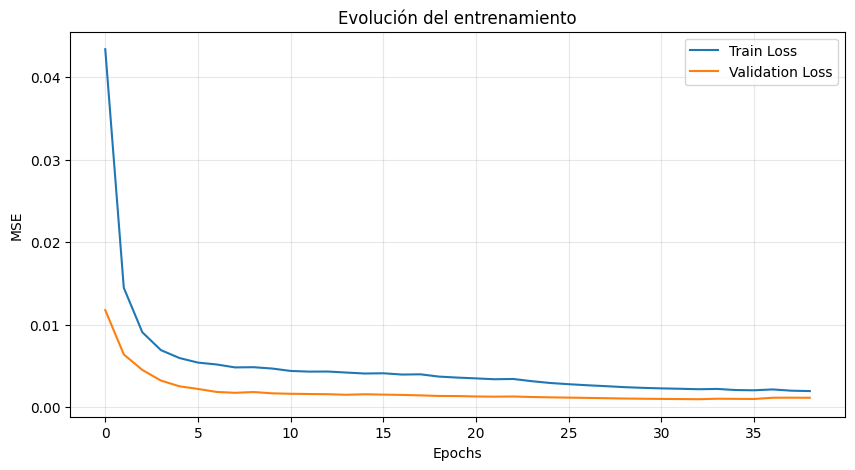

In [465]:
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Evolución del entrenamiento')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [24]:
def evaluar_modelo_lstm_temporal(model, X_val, y_val, scaler, fechas=None, muestras=None):
    """
    Evalúa el modelo y dibuja gráficos con un eje X temporal real.
    """
    print("Generando predicciones...")
    y_pred_scaled = model.predict(X_val)
    
    forma_original = y_val.shape
    y_pred_inv = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).reshape(forma_original)
    y_val_inv = scaler.inverse_transform(y_val.reshape(-1, 1)).reshape(forma_original)
    
    mse = mean_squared_error(y_val_inv, y_pred_inv)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_val_inv, y_pred_inv)
    mape = mean_absolute_percentage_error(y_val_inv, y_pred_inv) * 100 
    
    print("="*40)
    print(" MÉTRICAS DE RENDIMIENTO (En MW)")
    print("="*40)
    print(f"MSE:  {mse:.2f}")
    print(f"RMSE: {rmse:.2f} MW")
    print(f"MAE:  {mae:.2f} MW")
    print(f"MAPE: {mape:.2f} %")
    print("="*40)
    

    # GRÁFICOS CON EJE TEMPORAL
    
    fig, axes = plt.subplots(3, 1, figsize=(14, 18))
    
    # Si no nos pasan fechas, creamos un array numérico falso para que no dé error
    if fechas is None:
        fechas_plot = np.arange(len(y_val_inv))
    else:
        # Convertimos a formato datetime de pandas por si acaso
        fechas_plot = pd.to_datetime(fechas)
    
    # --- GRÁFICO 1: Predicción Continua (Primer paso de cada secuencia) ---
    if muestras:
        if muestras > len(y_val_inv):
            muestras = len(y_val_inv)
    else: 
        muestras = len(y_val_inv)
            
    axes[0].plot(fechas_plot[:muestras], y_val_inv[:muestras, 0], label='Real (MW)', color='#2980b9', linewidth=2)
    axes[0].plot(fechas_plot[:muestras], y_pred_inv[:muestras, 0], label='Predicción t+1', color='#e67e22', alpha=0.8, linewidth=2)
    
    axes[0].set_title('Predicción vs Realidad (Paso t+1)', fontweight='bold')
    axes[0].set_ylabel('Demanda (MW)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Formateo pro del eje temporal (Día y Hora)
    if fechas is not None:
        axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))
        # Ponemos una marca cada 12 horas para que no se superpongan los textos
        axes[0].xaxis.set_major_locator(mdates.HourLocator(interval=12)) 
        plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=15, ha="right")

    
    # --- GRÁFICO 2: Ejemplo de un Horizonte Completo (24 pasos) ---
    muestra_aleatoria = np.random.randint(0, len(y_val_inv))
    
    # Para el horizonte, calculamos las fechas de esos 24 pasos exactos
    if fechas is not None:
        fecha_inicio_horizonte = fechas_plot[muestra_aleatoria]
        # Generamos 24 rangos de 10 min a partir de esa fecha
        fechas_horizonte = pd.date_range(start=fecha_inicio_horizonte, periods=HORIZON, freq='10min')
    else:
        fechas_horizonte = np.arange(HORIZON)
        
    axes[1].plot(fechas_horizonte, y_val_inv[muestra_aleatoria, :], label='Horizonte Real', color='green', marker='o')
    axes[1].plot(fechas_horizonte, y_pred_inv[muestra_aleatoria, :], label='Predicción (4 horas)', color='red', marker='x', linestyle='--')
    
    axes[1].set_title(f'Detalle de un Horizonte de Predicción', fontweight='bold')
    axes[1].set_ylabel('Demanda (MW)')
    axes[1].legend()
    # Para el horizonte, calculamos las fechas de esos 24 pasos exactos
    if fechas is not None:
        fecha_inicio_horizonte = fechas_plot[muestra_aleatoria]
        # Generamos 24 rangos de 10 min a partir de esa fecha
        fechas_horizonte = pd.date_range(start=fecha_inicio_horizonte, periods=HORIZON, freq='10min')
    else:
        fechas_horizonte = np.arange(HORIZON)
        
    axes[1].plot(fechas_horizonte, y_val_inv[muestra_aleatoria, :], label='Horizonte Real', color='green', marker='o')
    axes[1].plot(fechas_horizonte, y_pred_inv[muestra_aleatoria, :], label='Predicción (4 horas)', color='red', marker='x', linestyle='--')
    
    axes[1].set_title(f'Detalle de un Horizonte de Predicción', fontweight='bold')
    axes[1].set_ylabel('Demanda (MW)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    if fechas is not None:
        axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        axes[1].xaxis.set_major_locator(mdates.MinuteLocator(byminute=[0, 30])) # Marcas cada media hora
        plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha="right")

    
    # --- GRÁFICO 3: Distribución de Residuos ---
    residuos = (y_val_inv - y_pred_inv).flatten()
    axes[2].hist(residuos, bins=50, color='purple', alpha=0.7, edgecolor='black')
    axes[2].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Error Cero')
    axes[2].set_title('Distribución de Errores (Residuos)', fontweight='bold')
    axes[2].set_xlabel('Error de predicción (MW)')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return y_pred_inv, y_val_inv, residuos

def evaluar_modelo_lstm(model, X_test, y_test, scaler, muestras_a_mostrar=None):
    """
    Genera predicciones, revierte el escalado, calcula métricas 
    y dibuja 3 gráficos de diagnóstico.
    """
    print("Generando predicciones...")
    # 1. Hacer predicciones (Saldrán escaladas entre 0 y 1)
    y_pred_scaled = model.predict(X_test)
    
    # 2. Desescalar los datos a la unidad original (MW)
    # Como y_test y y_pred tienen forma (muestras, HORIZON), necesitamos aplanarlos,
    # desescalarlos y volverlos a su forma original.
    forma_original = y_test.shape
    
    y_pred_inv = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).reshape(forma_original)
    y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(forma_original)
    
    # 3. Calcular Métricas Globales (sobre todos los pasos del horizonte)
    mse = mean_squared_error(y_test_inv, y_pred_inv)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_inv, y_pred_inv)
    # Evitamos división por cero en MAPE por si acaso
    mape = mean_absolute_percentage_error(y_test_inv, y_pred_inv) * 100 
    
    print("="*40)
    print(" MÉTRICAS DE RENDIMIENTO (En MW)")
    print("="*40)
    print(f"MSE:  {mse:.2f}")
    print(f"RMSE: {rmse:.2f} MW (Error promedio 'castigando' fallos grandes)")
    print(f"MAE:  {mae:.2f} MW (Error promedio absoluto)")
    print(f"MAPE: {mape:.2f} % (Porcentaje de error)")
    print("="*40)
    

    # GRÁFICOS DE DIAGNÓSTICO

    fig, axes = plt.subplots(3, 1, figsize=(14, 18))
    
    # --- GRÁFICO 1: Predicción Continua (Solo el paso t+1) ---
    # Para no ver una maraña de líneas superpuestas, comparamos 
    # cómo predice el modelo el primer paso (los próximos 10 min) a lo largo de toda la validación.
    if muestras_a_mostrar:
        if muestras_a_mostrar > len(y_test_inv):
            muestras_a_mostrar = len(y_test_inv)
    else: 
        muestras_a_mostrar = len(y_test_inv)
        
    axes[0].plot(y_test_inv[:muestras_a_mostrar, 0], label='Real (MW)', color='#2980b9', linewidth=2)
    axes[0].plot(y_pred_inv[:muestras_a_mostrar, 0], label='Predicción t+1', color='#e67e22', alpha=0.8, linewidth=2)
    axes[0].set_title(f'Visualización de la serie temporal ({muestras_a_mostrar} periodos)', fontweight='bold')
    axes[0].set_ylabel('Demanda (MW)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # --- GRÁFICO 2: Ejemplo de un Horizonte Completo (24 pasos / 4 horas) ---
    # Cogemos una muestra aleatoria para ver qué predijo exactamente el modelo para esas 4 horas
    muestra_aleatoria = np.random.randint(0, len(y_test_inv))
    
    axes[1].plot(y_test_inv[muestra_aleatoria, :], label='Horizonte Real', color='green', marker='o')
    axes[1].plot(y_pred_inv[muestra_aleatoria, :], label='Predicción del modelo', color='red', marker='x', linestyle='--')
    axes[1].set_title(f'Comportamiento en un horizonte predictivo de 4 horas (Muestra aleatoria #{muestra_aleatoria})', fontweight='bold')
    axes[1].set_xlabel('Pasos hacia el futuro (1 paso = 10 min)')
    axes[1].set_ylabel('Demanda (MW)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # --- GRÁFICO 3: Distribución de Errores (Residuos) ---
    # Calculamos la diferencia entre la predicción y la realidad
    residuos = (y_test_inv - y_pred_inv).flatten()
    
    axes[2].hist(residuos, bins=50, color='purple', alpha=0.7, edgecolor='black')
    axes[2].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Error Cero')
    axes[2].set_title('Distribución de Residuos (Errores)', fontweight='bold')
    axes[2].set_xlabel('Error de predicción (MW)')
    axes[2].set_ylabel('Frecuencia')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def graficar_dispersion_real_vs_predicho(y_test_inv, y_pred_inv):
    """
    Genera un gráfico de dispersión comparando todos los puntos reales
    contra sus respectivas predicciones, junto con la diagonal perfecta.
    """
    # 1. Aplanar los arrays
    # Como y_test_inv tiene forma (muestras, 24 pasos), lo aplanamos 
    # para comparar cada punto individual independientemente del horizonte.
    real_flat = y_test_inv.flatten()
    pred_flat = y_pred_inv.flatten()

    # 2. Encontrar los límites dinámicos para el gráfico
    # Buscamos el valor mínimo y máximo absoluto para dibujar la diagonal
    min_val = min(real_flat.min(), pred_flat.min())
    max_val = max(real_flat.max(), pred_flat.max())
    
    # Para que el gráfico no empiece pegado al borde, le damos un 5% de margen
    margen = (max_val - min_val) * 0.05
    lim_inf = min_val - margen
    lim_sup = max_val + margen

    # 3. Dibujar el gráfico
    plt.figure(figsize=(8, 8))
    
    # Los puntos (alpha bajo para que las zonas densas se vean más oscuras)
    plt.scatter(real_flat, pred_flat, alpha=0.3, color='#2980b9', edgecolors='none', s=20)
    
    # La línea de predicción perfecta (y = x)
    plt.plot([lim_inf, lim_sup], [lim_inf, lim_sup], color='red', linestyle='--', linewidth=2, label='Predicción Perfecta (y = x)')

    # 4. Formato y etiquetas
    plt.title('Dispersión: Demanda Real vs. Predicha', fontweight='bold', fontsize=14, pad=15)
    plt.xlabel('Demanda Real (MW)', fontweight='bold', fontsize=11)
    plt.ylabel('Demanda Predicha (MW)', fontweight='bold', fontsize=11)
    
    # Forzar que los ejes tengan exactamente la misma escala
    plt.xlim([lim_inf, lim_sup])
    plt.ylim([lim_inf, lim_sup])
    plt.gca().set_aspect('equal', adjustable='box') # Garantiza proporción 1:1
    
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def graficar_densidad_prediccion(y_val_inv, y_pred_inv):
    """
    Genera un gráfico que combina dispersión suave con curvas de nivel (KDE)
    para visualizar dónde se concentra el 90% de las predicciones reales del modelo.
    """
    
    # 1. Aplanar los arrays
    real_flat = y_val_inv.flatten()
    pred_flat = y_pred_inv.flatten()

    # 2. Límites del gráfico
    min_val = min(real_flat.min(), pred_flat.min())
    max_val = max(real_flat.max(), pred_flat.max())
    margen = (max_val - min_val) * 0.05
    lim_inf = min_val - margen
    lim_sup = max_val + margen

    # 3. Dibujar el gráfico
    plt.figure(figsize=(10, 10))
    
    # Capa 1: Los puntos originales (muy difuminados para que no molesten)
    plt.scatter(real_flat, pred_flat, alpha=0.3, color='gray', s=10, label='Puntos individuales')
    
    # Capa 2: Las curvas de nivel KDE
    # thresh=0.05 ignora el 5% de puntos más extremos para que los anillos se centren en lo importante
    sns.kdeplot(
        x=real_flat, 
        y=pred_flat, 
        cmap="Blues", 
        fill=True, 
        thresh=0.05, 
        levels=10, 
        alpha=0.7
    )

    # Capa 3: La línea de predicción perfecta
    plt.plot([lim_inf, lim_sup], [lim_inf, lim_sup], color='red', linestyle='--', linewidth=2.5, label='Predicción Perfecta (y = x)')

    # 4. Formato
    plt.title('Mapa de Densidad: Demanda Real vs. Predicha', fontweight='bold', fontsize=15, pad=15)
    plt.xlabel('Demanda Real (MW)', fontweight='bold', fontsize=12)
    plt.ylabel('Demanda Predicha (MW)', fontweight='bold', fontsize=12)
    
    # Proporción exacta 1:1
    plt.xlim([lim_inf, lim_sup])
    plt.ylim([lim_inf, lim_sup])
    plt.gca().set_aspect('equal', adjustable='box')
    
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
# 1. Definimos las fechas límite del test
target_start = pd.Timestamp('2015-06-08 00:00:00')
target_end   = pd.Timestamp('2015-06-14 23:50:00')

# 2. Encontramos los índices posicionales (enteros) de esas fechas
# Usamos .argmax() para encontrar la primera fila que cumple o supera la fecha
target_idx_start = (df_train['date_hour'] >= target_start).argmax()
target_idx_end   = (df_train['date_hour'] >= target_end).argmax()

# 3. Ajustamos los márgenes para el slicing
# Retrocedemos LOOKBACK para tener historia en la primera predicción
inicio_test_con_historia = target_idx_start - LOOKBACK

# Sumamos HORIZON para que la última secuencia (en target_idx_end) 
# tenga datos "futuros" suficientes para construir su vector 'y'
fin_test = target_idx_end + HORIZON 

# 4. Extraemos la porción de datos del array multivariante
test_data = dataset_multivariante[inicio_test_con_historia : fin_test]

# 5. Creamos las secuencias
X_test, y_test = create_sequences_multivariate(test_data, LOOKBACK, HORIZON)

print(f"Test configurado desde {target_start} hasta {target_end}")
print(f"Dimensión de X_test: {X_test.shape}") # Debería tener las filas exactas entre esas fechas

# 6. Extraemos las fechas correspondientes a cada predicción
# Esto sirve para graficar: cada X_test[i] predice a partir de esta fecha
fechas_test = df_train['date_hour'].iloc[target_idx_start : target_idx_start + len(X_test)].values

Dimensión de X_test: (1008, 144, 5)


Generando predicciones...
 1/32 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
 MÉTRICAS DE RENDIMIENTO (En MW)
MSE:  671902.54
RMSE: 819.70 MW
MAE:  652.92 MW
MAPE: 2.29 %


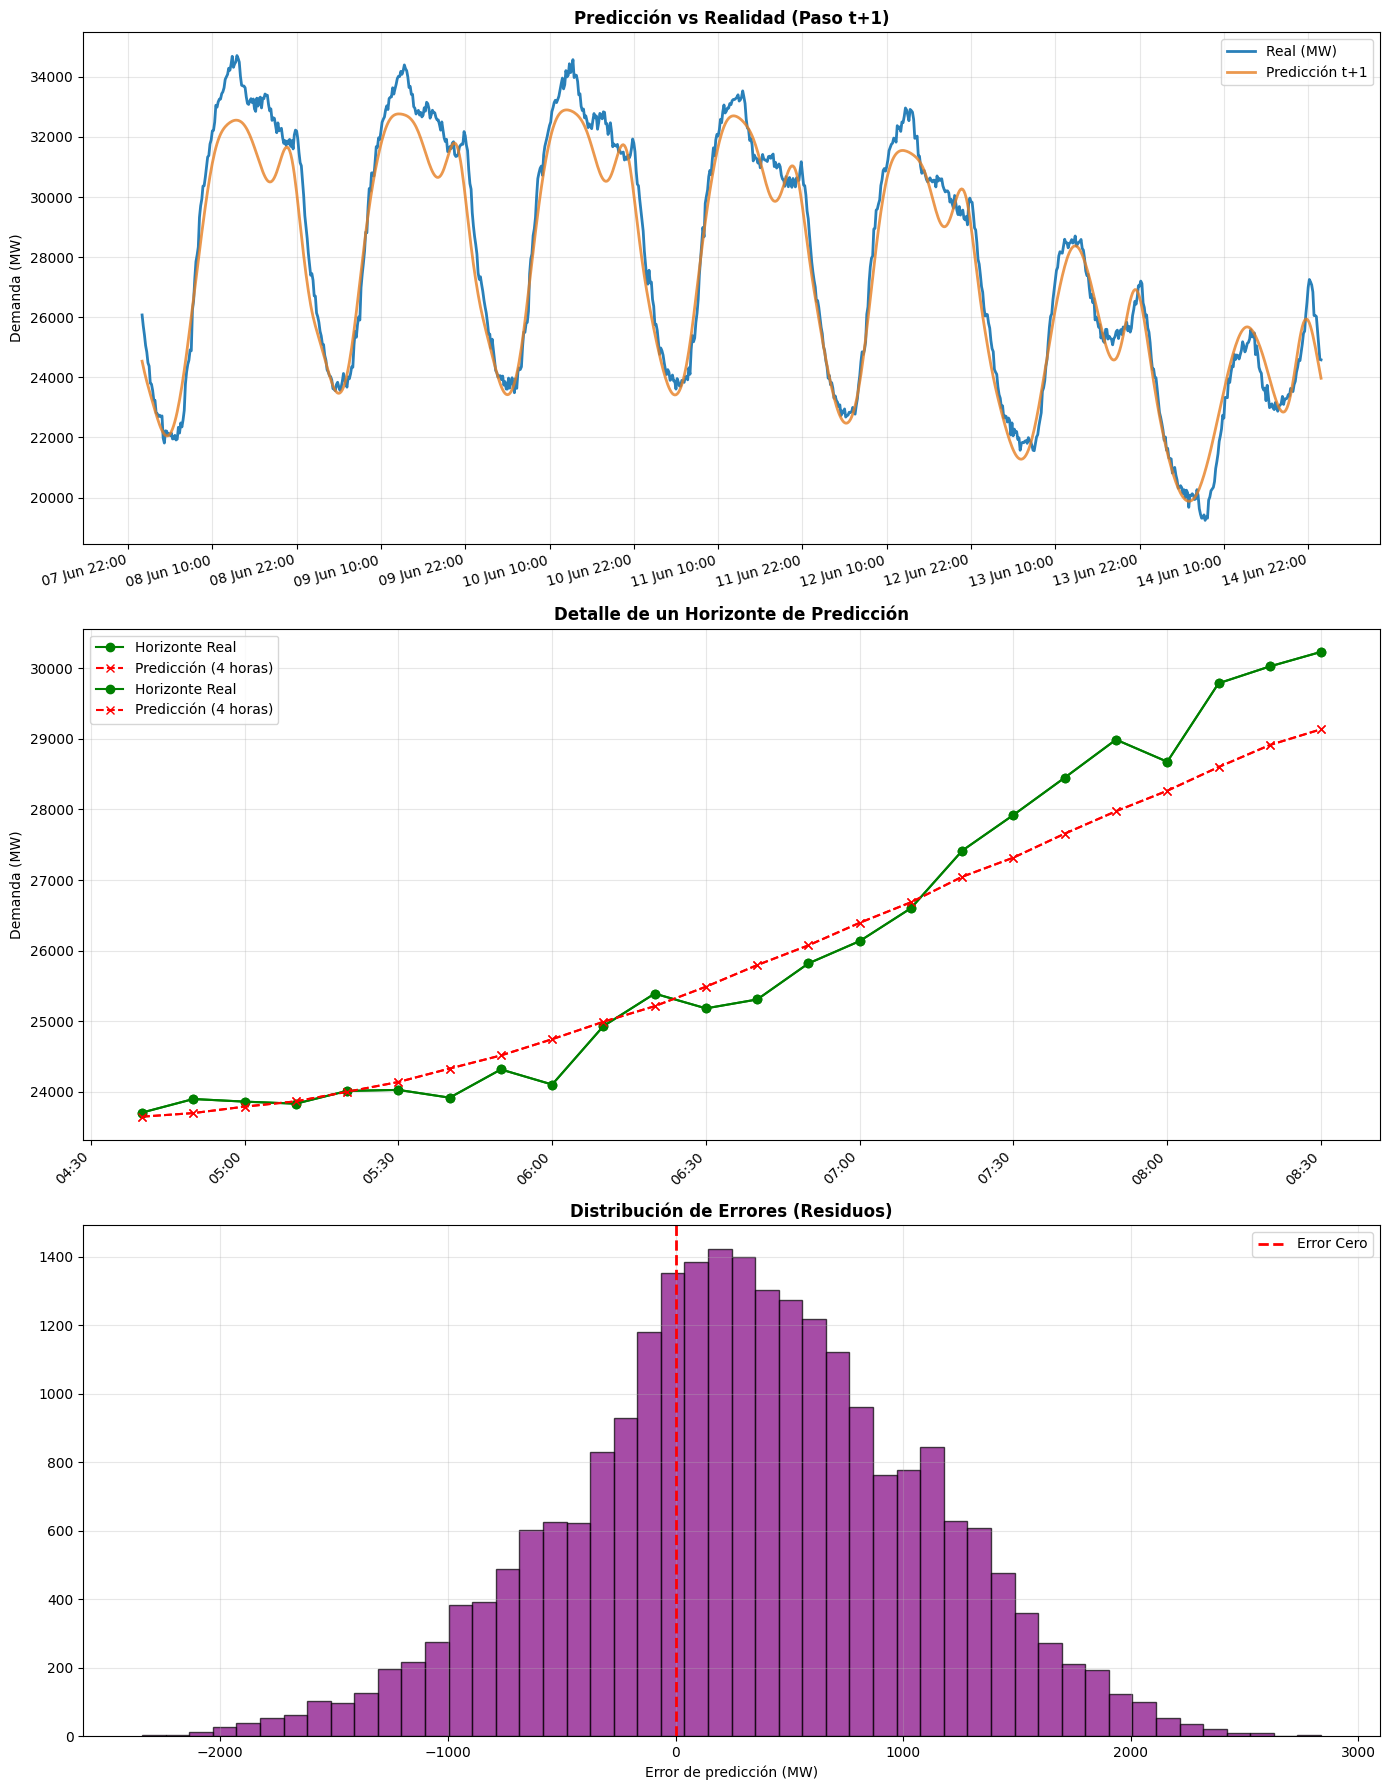

In [490]:
y_pred_inv, y_test_inv, residuos = evaluar_modelo_lstm_temporal(model, X_test, y_test, scaler, fechas=fechas_test)

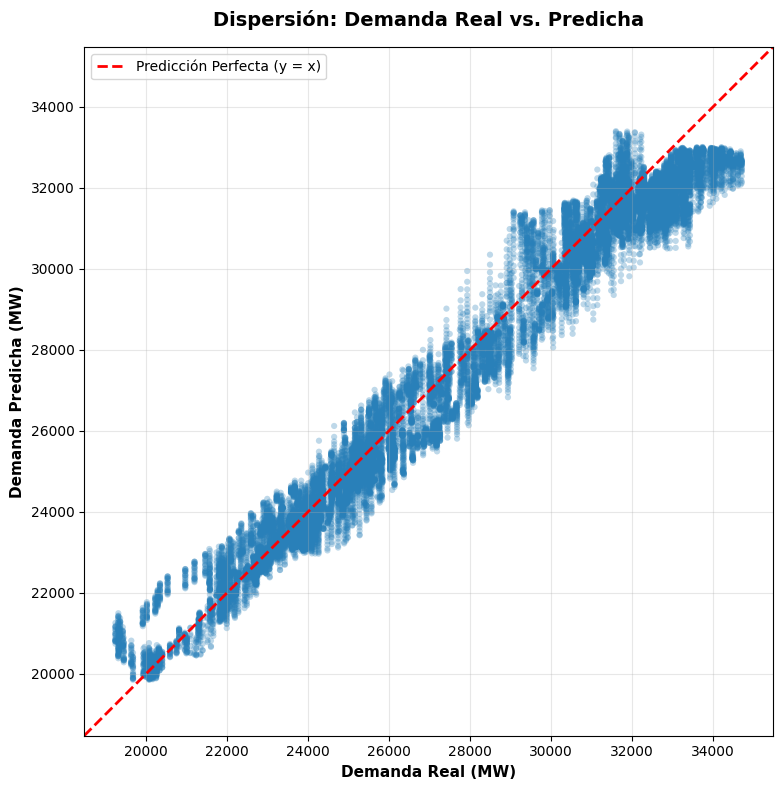

In [491]:
graficar_dispersion_real_vs_predicho(y_test_inv, y_pred_inv)

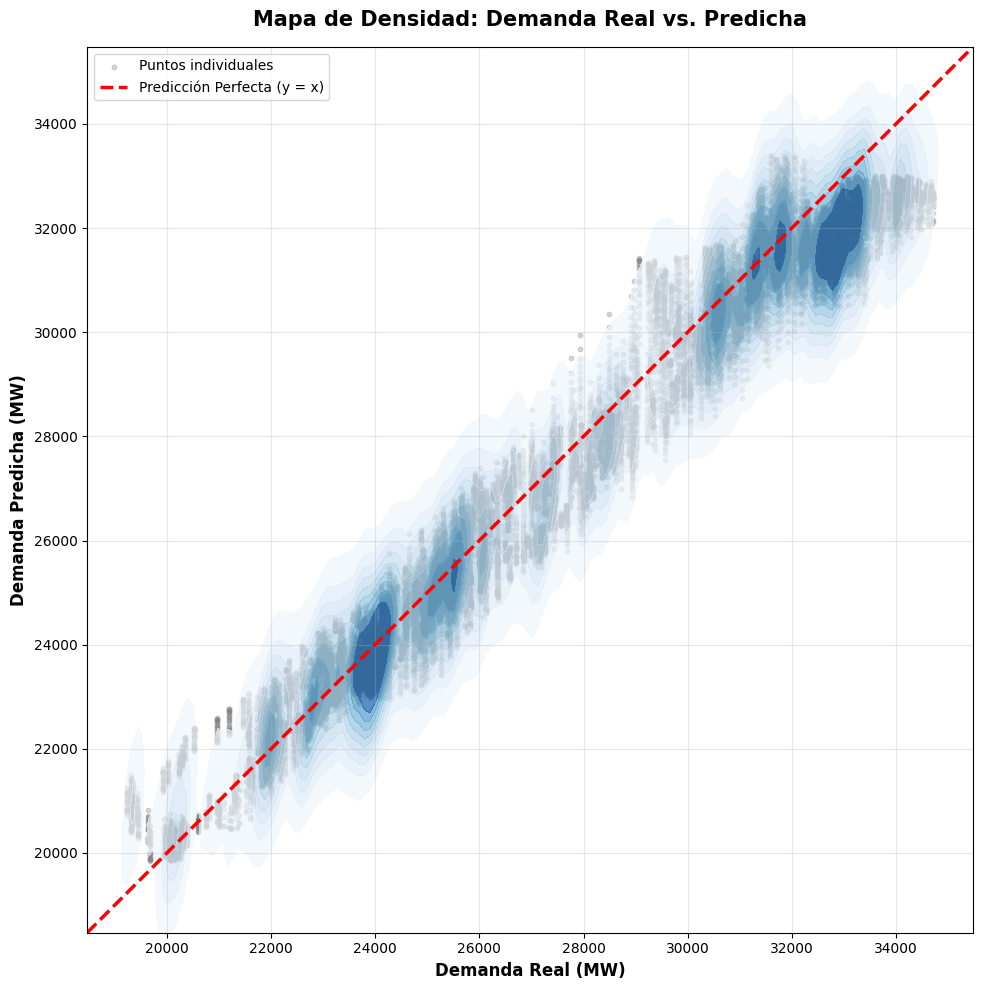

In [492]:
graficar_densidad_prediccion(y_test_inv, y_pred_inv)

## 5. Guardamos los resultados

In [499]:
fechas_test

array(['2015-06-08T00:00:00.000000', '2015-06-08T00:10:00.000000',
       '2015-06-08T00:20:00.000000', ..., '2015-06-14T23:30:00.000000',
       '2015-06-14T23:40:00.000000', '2015-06-14T23:50:00.000000'],
      shape=(1008,), dtype='datetime64[us]')

In [510]:
df_resultados_pred = pd.DataFrame(y_pred_inv)
df_resultados_pred['fecha'] = fechas_test
df_resultados_pred.set_index('fecha', inplace=True)

In [512]:
df_resultados_pred.to_csv('predicciones_lstm_multivariante.csv')

In [513]:
df_resultados_test = pd.DataFrame(y_test_inv)
df_resultados_test['fecha'] = fechas_test
df_resultados_test.set_index('fecha', inplace=True)

In [515]:
df_resultados_test.to_csv('reales_lstm_multivariante.csv')

In [519]:
df_mape = np.abs(df_resultados_test - df_resultados_pred)/ df_resultados_test
df_mape.to_csv('mape_lstm_multivariante.csv')